## 1) Configuracion e importacion de librerias

Si te falta alguna libreria en Jupyter, instala desde una celda asi:

```python
%pip install pandas numpy matplotlib
```


In [60]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
plt.style.use('seaborn-v0_8-whitegrid')


## 2) Cargar datos

In [61]:
candidatos = [Path('datos_unificadosF.csv'), Path('datos_unificados.csv')]
input_file = next((p for p in candidatos if p.exists()), None)

if input_file is None:
    raise FileNotFoundError('No se encontro datos_unificadosF.csv ni datos_unificados.csv en esta carpeta.')

print(f'Archivo detectado: {input_file.resolve()}')

df_raw = pd.read_csv(input_file, encoding='utf-8-sig', low_memory=False)
print('Shape original:', df_raw.shape)
display(df_raw.head())


Archivo detectado: /Users/retailcpu3/Documents/Mineria de Datos/Proyecto1MineriaDatos/datos_unificadosF.csv
Shape original: (69944, 45)


,DEPREG,MUPREG,MESREG,AÑOREG,DIAOCU,MESOCU,DEPOCU,MUPOCU,EDADHOM,EDADMUJ,GETHOM,GETMUJ,NACHOM,NACMUJ,ESCHOM,ESCMUJ,OCUHOM,OCUMUJ,origen_archivo,PUEHOM,PUEMUJ,CIUOHOM,CIUOMUJ,depreg,mupreg,mesreg,añoreg,diaocu,mesocu,añoocu,depocu,mupocu,edadhom,edadmuj,grethom,gretmuj,nachom,nacmuj,escohom,escomuj,ocupahom,ocupamuj,AÑOOCU,PPERHOM,PPERMUJ
0,17.0,1708.0,3.0,2012.0,16.0,2.0,17.0,1703.0,999.0,33.0,9.0,2.0,320.0,320.0,9.0,4.0,9712.0,110.0,Divorcios12.sav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12.0,1213.0,5.0,2012.0,3.0,2.0,12.0,1215.0,35.0,30.0,2.0,2.0,320.0,320.0,5.0,9.0,110.0,1120.0,Divorcios12.sav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,101.0,4.0,2012.0,27.0,3.0,1.0,101.0,33.0,32.0,9.0,2.0,320.0,320.0,5.0,5.0,2142.0,1120.0,Divorcios12.sav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,14.0,1416.0,6.0,2012.0,28.0,5.0,14.0,1401.0,31.0,28.0,9.0,2.0,320.0,320.0,1.0,4.0,8189.0,1120.0,Divorcios12.sav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,101.0,10.0,2012.0,12.0,3.0,1.0,101.0,27.0,29.0,2.0,2.0,320.0,320.0,4.0,5.0,1346.0,1212.0,Divorcios12.sav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3) Normalizacion de nombres y unificacion de columnas historicas

In [62]:
def normalizar_nombre(col):
    col = str(col).strip().lower()
    col = unicodedata.normalize('NFKD', col)
    col = ''.join(ch for ch in col if not unicodedata.combining(ch))
    col = re.sub(r'[^a-z0-9]+', '_', col).strip('_')
    return col

# Copia de trabajo
_df = df_raw.copy()
_df.columns = [normalizar_nombre(c) for c in _df.columns]

# Mapa de aliases -> variable canonica
aliases = {
    'depreg': ['depreg'],
    'mupreg': ['mupreg'],
    'mesreg': ['mesreg'],
    'anoreg': ['anoreg'],
    'diaocu': ['diaocu'],
    'mesocu': ['mesocu'],
    'anoocu': ['anoocu'],
    'depocu': ['depocu'],
    'mupocu': ['mupocu'],
    'edadhom': ['edadhom'],
    'edadmuj': ['edadmuj'],
    'gethom': ['gethom', 'grethom'],
    'getmuj': ['getmuj', 'gretmuj'],
    'nachom': ['nachom'],
    'nacmuj': ['nacmuj'],
    'eschom': ['eschom', 'escohom'],
    'escmuj': ['escmuj', 'escomuj'],
    'ocuhom': ['ocuhom', 'ocupahom'],
    'ocumuj': ['ocumuj', 'ocupamuj'],
    'puehom': ['puehom'],
    'puemuj': ['puemuj'],
    'ciuohom': ['ciuohom'],
    'ciuomuj': ['ciuomuj'],
    'pperhom': ['pperhom'],
    'ppermuj': ['ppermuj'],
    'origen_archivo': ['origen_archivo'],
}

# Unificar columnas: toma el primer valor no nulo entre aliases
# Nota: _df puede tener nombres duplicados, y pandas los maneja.
df = pd.DataFrame(index=_df.index)
for canonica, candidatas in aliases.items():
    existentes = [c for c in candidatas if c in _df.columns]
    if not existentes:
        df[canonica] = np.nan
    else:
        df[canonica] = _df[existentes].bfill(axis=1).iloc[:, 0]

# Espacios vacios -> NA
df = df.replace(r'^\s*$', pd.NA, regex=True)

print('Shape unificado:', df.shape)
display(df.head())


Shape unificado: (69944, 26)


,depreg,mupreg,mesreg,anoreg,diaocu,mesocu,anoocu,depocu,mupocu,edadhom,edadmuj,gethom,getmuj,nachom,nacmuj,eschom,escmuj,ocuhom,ocumuj,puehom,puemuj,ciuohom,ciuomuj,pperhom,ppermuj,origen_archivo
0,17.0,1708.0,3.0,2012.0,16.0,2.0,NaN,17.0,1703.0,999.0,33.0,9.0,2.0,320.0,320.0,9.0,4.0,9712.0,110.0,NaN,NaN,NaN,NaN,NaN,NaN,Divorcios12.sav
1,12.0,1213.0,5.0,2012.0,3.0,2.0,NaN,12.0,1215.0,35.0,30.0,2.0,2.0,320.0,320.0,5.0,9.0,110.0,1120.0,NaN,NaN,NaN,NaN,NaN,NaN,Divorcios12.sav
2,1.0,101.0,4.0,2012.0,27.0,3.0,NaN,1.0,101.0,33.0,32.0,9.0,2.0,320.0,320.0,5.0,5.0,2142.0,1120.0,NaN,NaN,NaN,NaN,NaN,NaN,Divorcios12.sav
3,14.0,1416.0,6.0,2012.0,28.0,5.0,NaN,14.0,1401.0,31.0,28.0,9.0,2.0,320.0,320.0,1.0,4.0,8189.0,1120.0,NaN,NaN,NaN,NaN,NaN,NaN,Divorcios12.sav
4,1.0,101.0,10.0,2012.0,12.0,3.0,NaN,1.0,101.0,27.0,29.0,2.0,2.0,320.0,320.0,4.0,5.0,1346.0,1212.0,NaN,NaN,NaN,NaN,NaN,NaN,Divorcios12.sav


## 4) Limpieza basica de tipos (numericas y categoricas)

In [63]:
numeric_specs = {
    'mesreg': {'min': 1, 'max': 12, 'invalid': [99, 999]},
    'anoreg': {'min': 1950, 'max': 2100, 'invalid': [99, 999, 9999]},
    'diaocu': {'min': 1, 'max': 31, 'invalid': [99, 999]},
    'mesocu': {'min': 1, 'max': 12, 'invalid': [99, 999]},
    'anoocu': {'min': 1950, 'max': 2100, 'invalid': [99, 999, 9999]},
    'edadhom': {'min': 10, 'max': 110, 'invalid': [-1, 0, 99, 999, 9999]},
    'edadmuj': {'min': 10, 'max': 110, 'invalid': [-1, 0, 99, 999, 9999]},
}

categorical_cols = [
    'depreg', 'mupreg', 'depocu', 'mupocu', 'gethom', 'getmuj',
    'nachom', 'nacmuj', 'eschom', 'escmuj', 'ocuhom', 'ocumuj',
    'puehom', 'puemuj', 'ciuohom', 'ciuomuj', 'pperhom', 'ppermuj',
    'origen_archivo'
]

def limpiar_numerica(serie, spec):
    s = pd.to_numeric(serie, errors='coerce')
    invalidos = spec.get('invalid', [])
    if invalidos:
        s = s.mask(s.isin(invalidos))
    if 'min' in spec:
        s = s.mask(s < spec['min'])
    if 'max' in spec:
        s = s.mask(s > spec['max'])
    return s

def limpiar_categorica(serie, pad4=False):
    s = serie.astype('string').str.strip()
    s = s.replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA, '<NA>': pd.NA})
    s = s.str.replace(r'\.0$', '', regex=True)
    if pad4:
        s = s.where(s.isna(), s.str.zfill(4))
    return s

for col, spec in numeric_specs.items():
    if col in df.columns:
        df[col] = limpiar_numerica(df[col], spec)

for col in categorical_cols:
    if col in df.columns:
        df[col] = limpiar_categorica(df[col], pad4=(col in ['mupreg', 'mupocu']))

print('Tipos despues de limpieza:')
display(df.dtypes)


Tipos despues de limpieza:


depreg             string
mupreg             string
mesreg            float64
anoreg            float64
diaocu            float64
mesocu            float64
anoocu            float64
depocu             string
mupocu             string
edadhom           float64
edadmuj           float64
gethom             string
getmuj             string
nachom             string
nacmuj             string
eschom             string
escmuj             string
ocuhom             string
ocumuj             string
puehom             string
puemuj             string
ciuohom            string
ciuomuj            string
pperhom            string
ppermuj            string
origen_archivo     string
dtype: object

## 5) Descripcion general del conjunto de datos

In [64]:
n_obs = len(df)
n_vars = df.shape[1]

rango_anio = (int(df['anoreg'].min()), int(df['anoreg'].max())) if df['anoreg'].notna().any() else (None, None)

print('Cantidad de observaciones:', f'{n_obs:,}')
print('Cantidad de variables:', n_vars)
print('Cobertura temporal (anoreg):', rango_anio)

print('\nCompletitud por variable (% no nulo):')
completitud = (df.notna().mean() * 100).sort_values(ascending=False).rename('pct_no_nulo').to_frame()
display(completitud)


Cantidad de observaciones: 69,944
Cantidad de variables: 26
Cobertura temporal (anoreg): (2010, 2023)

Completitud por variable (% no nulo):


,pct_no_nulo
depreg,100.000000
mupreg,100.000000
mesreg,100.000000
anoreg,100.000000
diaocu,100.000000
mesocu,100.000000
depocu,100.000000
mupocu,100.000000
eschom,100.000000
escmuj,100.000000


## 6) Significado y tipo de cada variable

In [65]:
var_info = [
    ('depreg', 'categorica', 'Departamento donde se registro el divorcio (codigo INE).'),
    ('mupreg', 'categorica', 'Municipio donde se registro el divorcio (codigo INE).'),
    ('mesreg', 'numerica discreta', 'Mes de registro del divorcio.'),
    ('anoreg', 'numerica discreta', 'Anio de registro del divorcio.'),
    ('diaocu', 'numerica discreta', 'Dia de ocurrencia del divorcio.'),
    ('mesocu', 'numerica discreta', 'Mes de ocurrencia del divorcio.'),
    ('anoocu', 'numerica discreta', 'Anio de ocurrencia del divorcio.'),
    ('depocu', 'categorica', 'Departamento de ocurrencia del divorcio (codigo INE).'),
    ('mupocu', 'categorica', 'Municipio de ocurrencia del divorcio (codigo INE).'),
    ('edadhom', 'numerica discreta', 'Edad del hombre al momento del divorcio.'),
    ('edadmuj', 'numerica discreta', 'Edad de la mujer al momento del divorcio.'),
    ('gethom', 'categorica', 'Codigo de grupo etnico del hombre (catalogo INE).'),
    ('getmuj', 'categorica', 'Codigo de grupo etnico de la mujer (catalogo INE).'),
    ('nachom', 'categorica', 'Codigo de nacionalidad del hombre (catalogo INE).'),
    ('nacmuj', 'categorica', 'Codigo de nacionalidad de la mujer (catalogo INE).'),
    ('eschom', 'categorica', 'Codigo de escolaridad del hombre (catalogo INE).'),
    ('escmuj', 'categorica', 'Codigo de escolaridad de la mujer (catalogo INE).'),
    ('ocuhom', 'categorica', 'Codigo de ocupacion del hombre (catalogo INE/CIUO).'),
    ('ocumuj', 'categorica', 'Codigo de ocupacion de la mujer (catalogo INE/CIUO).'),
    ('puehom', 'categorica', 'Codigo de pueblo/pertenencia del hombre.'),
    ('puemuj', 'categorica', 'Codigo de pueblo/pertenencia de la mujer.'),
    ('ciuohom', 'categorica', 'Codigo CIUO resumido de ocupacion del hombre.'),
    ('ciuomuj', 'categorica', 'Codigo CIUO resumido de ocupacion de la mujer.'),
    ('pperhom', 'categorica', 'Codigo adicional de pertenencia del hombre.'),
    ('ppermuj', 'categorica', 'Codigo adicional de pertenencia de la mujer.'),
    ('origen_archivo', 'texto', 'Archivo .sav de origen.'),
]

diccionario = pd.DataFrame(var_info, columns=['variable', 'tipo', 'descripcion'])
diccionario['no_nulos'] = diccionario['variable'].map(lambda c: df[c].notna().sum() if c in df.columns else 0)
diccionario['nulos'] = len(df) - diccionario['no_nulos']
diccionario['pct_completitud'] = (diccionario['no_nulos'] / len(df) * 100).round(2)

display(diccionario)


,variable,tipo,descripcion,no_nulos,nulos,pct_completitud
0,depreg,categorica,Departamento donde se registro el divorcio (co...,69944,0,100.00
1,mupreg,categorica,Municipio donde se registro el divorcio (codig...,69944,0,100.00
2,mesreg,numerica discreta,Mes de registro del divorcio.,69944,0,100.00
3,anoreg,numerica discreta,Anio de registro del divorcio.,69944,0,100.00
4,diaocu,numerica discreta,Dia de ocurrencia del divorcio.,69944,0,100.00
5,mesocu,numerica discreta,Mes de ocurrencia del divorcio.,69944,0,100.00
6,anoocu,numerica discreta,Anio de ocurrencia del divorcio.,53670,16274,76.73
7,depocu,categorica,Departamento de ocurrencia del divorcio (codig...,69944,0,100.00
8,mupocu,categorica,Municipio de ocurrencia del divorcio (codigo I...,69944,0,100.00
9,edadhom,numerica discreta,Edad del hombre al momento del divorcio.,32830,37114,46.94


## 7) Exploracion de variables numericas (tendencia central, distribucion y orden)

In [66]:
numeric_cols = [c for c in ['mesreg', 'anoreg', 'diaocu', 'mesocu', 'anoocu', 'edadhom', 'edadmuj'] if c in df.columns]

resumen_num = pd.DataFrame(index=numeric_cols)
resumen_num['n_validos'] = df[numeric_cols].notna().sum()
resumen_num['n_faltantes'] = len(df) - resumen_num['n_validos']
resumen_num['pct_faltantes'] = (resumen_num['n_faltantes'] / len(df) * 100)

resumen_num['media'] = df[numeric_cols].mean()
resumen_num['mediana'] = df[numeric_cols].median()
resumen_num['moda'] = [df[c].mode(dropna=True).iloc[0] if not df[c].mode(dropna=True).empty else np.nan for c in numeric_cols]

resumen_num['desv_std'] = df[numeric_cols].std()
resumen_num['varianza'] = df[numeric_cols].var()
resumen_num['minimo'] = df[numeric_cols].min()
resumen_num['q1'] = df[numeric_cols].quantile(0.25)
resumen_num['q3'] = df[numeric_cols].quantile(0.75)
resumen_num['maximo'] = df[numeric_cols].max()
resumen_num['rango'] = resumen_num['maximo'] - resumen_num['minimo']
resumen_num['iqr'] = resumen_num['q3'] - resumen_num['q1']
resumen_num['p10'] = df[numeric_cols].quantile(0.10)
resumen_num['p90'] = df[numeric_cols].quantile(0.90)
resumen_num['asimetria'] = df[numeric_cols].skew(numeric_only=True)
resumen_num['curtosis'] = df[numeric_cols].kurtosis(numeric_only=True)

resumen_num = resumen_num.round(4)
display(resumen_num)


,n_validos,n_faltantes,pct_faltantes,media,mediana,moda,desv_std,varianza,minimo,q1,q3,maximo,rango,iqr,p10,p90,asimetria,curtosis
mesreg,69944,0,0.0000,6.5757,7.0,10.0,3.4118,11.6406,1.0,4.0,10.0,12.0,11.0,6.0,2.0,11.0,-0.0430,-1.2111
anoreg,69944,0,0.0000,2016.5219,2017.0,2022.0,3.6369,13.2269,2010.0,2013.0,2019.0,2023.0,13.0,6.0,2011.0,2022.0,-0.0173,-1.0496
diaocu,69944,0,0.0000,15.7214,16.0,18.0,8.6964,75.6268,1.0,8.0,23.0,31.0,30.0,15.0,4.0,28.0,0.0111,-1.1938
mesocu,69944,0,0.0000,6.3271,6.0,10.0,3.3000,10.8901,1.0,3.0,9.0,12.0,11.0,6.0,2.0,11.0,0.0204,-1.1672
anoocu,53670,16274,23.2672,2017.2969,2018.0,2022.0,3.5682,12.7319,2010.0,2015.0,2020.0,2022.0,12.0,5.0,2011.0,2022.0,-0.5843,-0.4142
edadhom,32830,37114,53.0624,35.8522,34.0,31.0,10.1036,102.0821,15.0,29.0,41.0,96.0,81.0,12.0,25.0,50.0,1.1436,1.5363
edadmuj,32968,36976,52.8651,32.5787,31.0,27.0,9.2294,85.1827,14.0,26.0,38.0,80.0,66.0,12.0,23.0,45.0,1.0326,1.2076


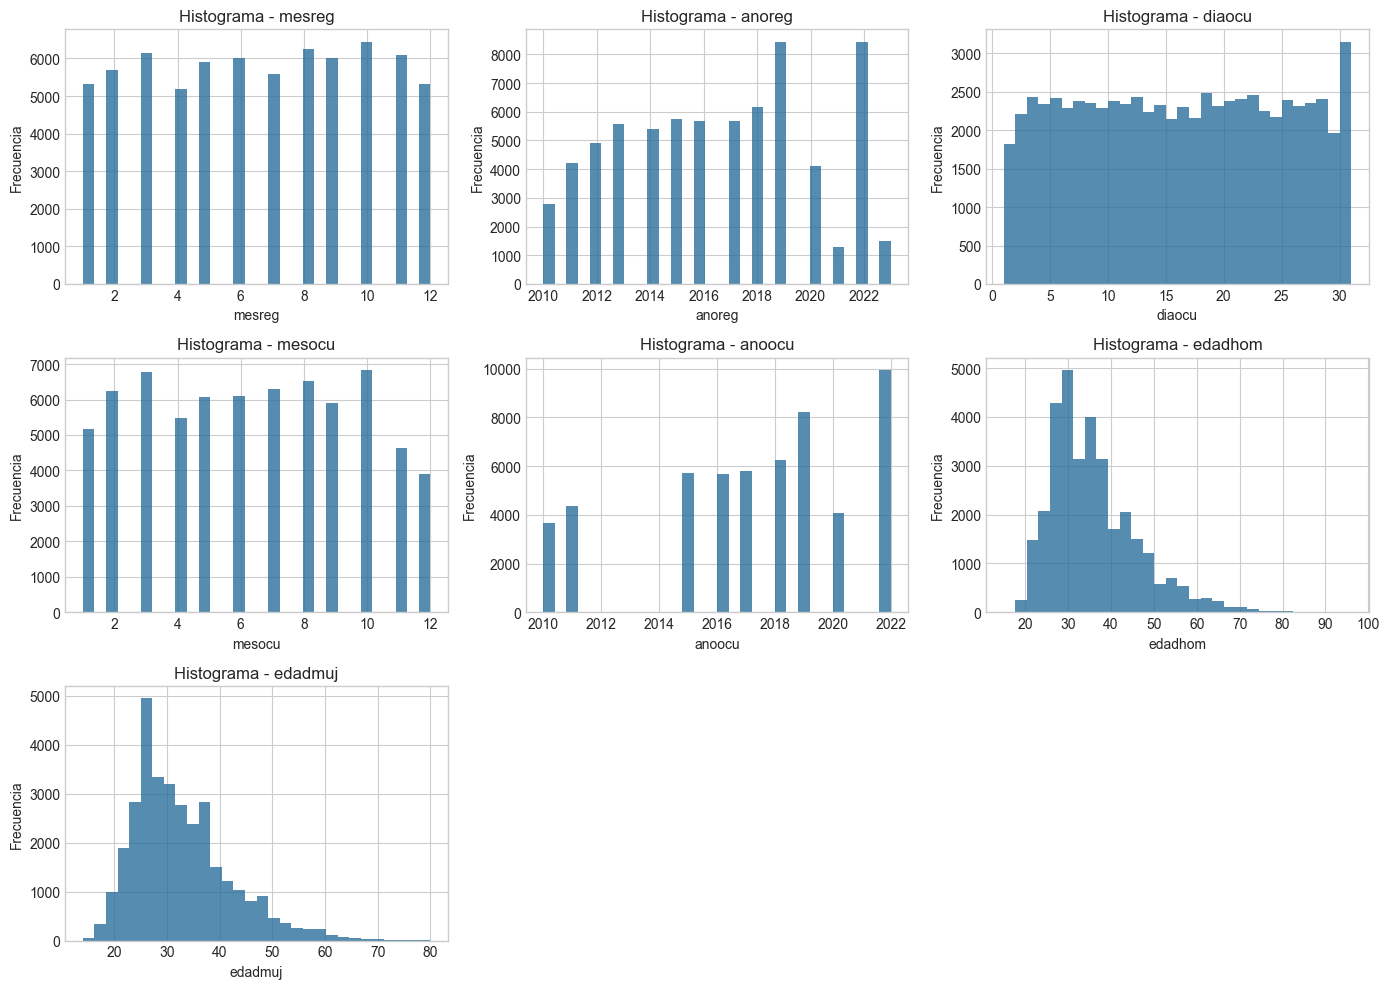

In [67]:
# Distribuciones numericas: histogramas
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#2a6f9b', alpha=0.8)
    axes[i].set_title(f'Histograma - {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


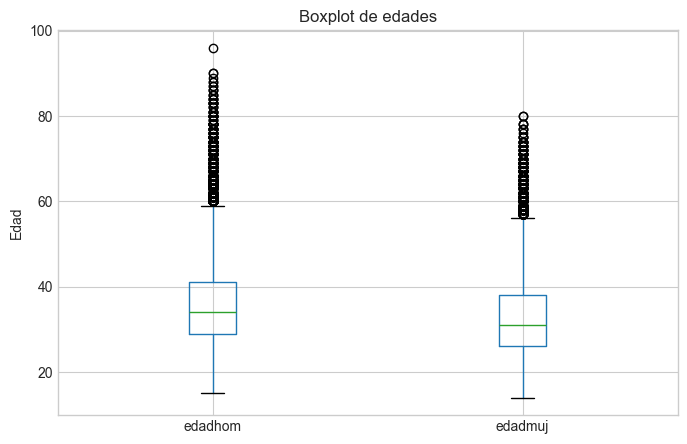

In [68]:
# Caja y bigotes para edades
cols_edad = [c for c in ['edadhom', 'edadmuj'] if c in df.columns]
if cols_edad:
    plt.figure(figsize=(8, 5))
    df[cols_edad].boxplot()
    plt.title('Boxplot de edades')
    plt.ylabel('Edad')
    plt.show()


## 8) Exploracion de variables categoricas y tablas de frecuencia

In [69]:
def tabla_frecuencia(dataframe, col, top=None):
    tabla = (
        dataframe[col]
        .value_counts(dropna=False)
        .rename_axis('categoria')
        .reset_index(name='frecuencia')
    )
    tabla['porcentaje'] = (tabla['frecuencia'] / len(dataframe) * 100).round(4)
    if top is not None:
        tabla = tabla.head(top)
    return tabla

categoricas = [
    'depreg', 'mupreg', 'depocu', 'mupocu', 'gethom', 'getmuj',
    'nachom', 'nacmuj', 'eschom', 'escmuj', 'ocuhom', 'ocumuj',
    'puehom', 'puemuj', 'ciuohom', 'ciuomuj', 'pperhom', 'ppermuj',
    'origen_archivo'
]

tablas_freq = {}
for col in categoricas:
    if col in df.columns:
        tablas_freq[col] = tabla_frecuencia(df, col, top=None)

print('Variables categoricas procesadas:', len(tablas_freq))


Variables categoricas procesadas: 19


In [70]:
# Ejemplo: top 15 para variables clave
for col in ['depreg', 'depocu', 'eschom', 'escmuj', 'gethom', 'getmuj', 'origen_archivo']:
    if col in tablas_freq:
        print('\n' + '='*90)
        print(f'Tabla de frecuencia: {col}')
        display(tablas_freq[col].head(15))



Tabla de frecuencia: depreg


,categoria,frecuencia,porcentaje
0,1,27308,39.0427
1,9,5343,7.639
2,5,3201,4.5765
3,22,2722,3.8917
4,12,2654,3.7945
5,10,2368,3.3856
6,13,2229,3.1868
7,18,2208,3.1568
8,11,2018,2.8852
9,17,1921,2.7465



Tabla de frecuencia: depocu


,categoria,frecuencia,porcentaje
0,1,26550,37.9589
1,9,5195,7.4274
2,5,3313,4.7366
3,22,3069,4.3878
4,12,2799,4.0018
5,10,2580,3.6887
6,13,2287,3.2698
7,18,2257,3.2269
8,11,1998,2.8566
9,14,1918,2.7422



Tabla de frecuencia: eschom


...

,categoria,frecuencia,porcentaje
0,<NA>,56798,81.205
1,9,10139,14.4959
2,2,2424,3.4656
3,1,583,0.8335



Tabla de frecuencia: getmuj


,categoria,frecuencia,porcentaje
0,<NA>,56798,81.205
1,9,10164,14.5316
2,2,2447,3.4985
3,1,535,0.7649



Tabla de frecuencia: origen_archivo


,categoria,frecuencia,porcentaje
0,Divorcios09.sav,9950,14.2257
1,Divorcios19.sav,8203,11.728
2,Divorcios18.sav,6255,8.9429
3,Divorcios17.sav,5808,8.3038
4,Divorcios15.sav,5726,8.1865
5,Divorcios16.sav,5665,8.0993
6,Divorcios14.sav,5575,7.9707
7,Divorcios13.sav,5542,7.9235
8,Divorcios12.sav,5157,7.373
9,Divorcios11.sav,4344,6.2107


## 9) Relaciones entre variables

,anoreg,divorcios
0,2010,2792
1,2011,4223
2,2012,4927
3,2013,5581
4,2014,5392
5,2015,5735
6,2016,5674
7,2017,5694
8,2018,6158
9,2019,8430


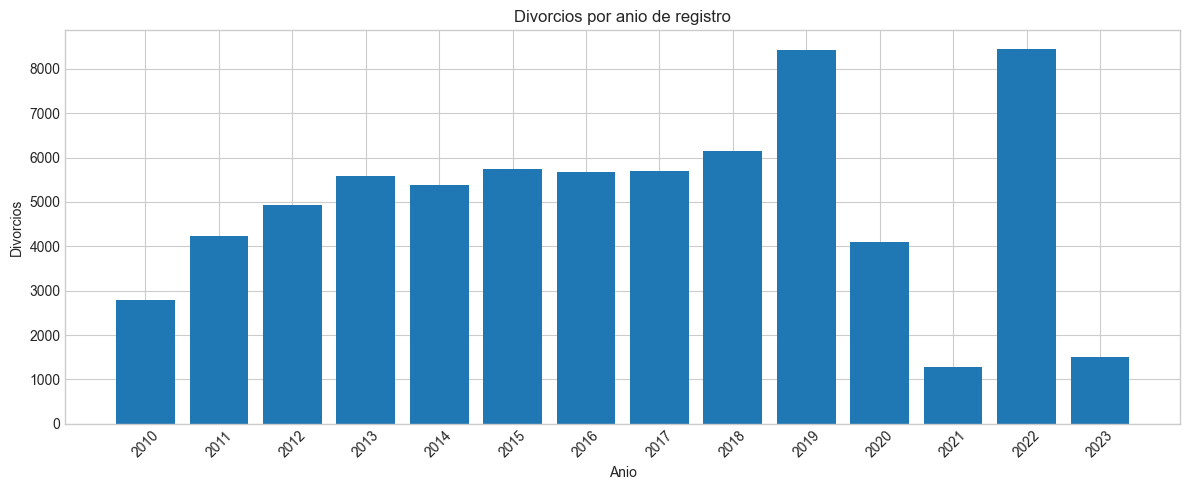

In [71]:
# 9.1 Divorcios por anio de registro
if 'anoreg' in df.columns:
    divorcios_por_anio = (
        df['anoreg']
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
        .rename_axis('anoreg')
        .reset_index(name='divorcios')
    )
    display(divorcios_por_anio)

    plt.figure(figsize=(12, 5))
    plt.bar(divorcios_por_anio['anoreg'], divorcios_por_anio['divorcios'])
    plt.title('Divorcios por anio de registro')
    plt.xlabel('Anio')
    plt.ylabel('Divorcios')
    plt.xticks(divorcios_por_anio['anoreg'], rotation=45)
    plt.tight_layout()
    plt.show()


,depreg,divorcios,departamento
0,1,27308,Guatemala
1,9,5343,Quetzaltenango
2,5,3201,Escuintla
3,22,2722,Jutiapa
4,12,2654,San Marcos
5,10,2368,Suchitepequez
6,13,2229,Huehuetenango
7,18,2208,Izabal
8,11,2018,Retalhuleu
9,17,1921,Peten


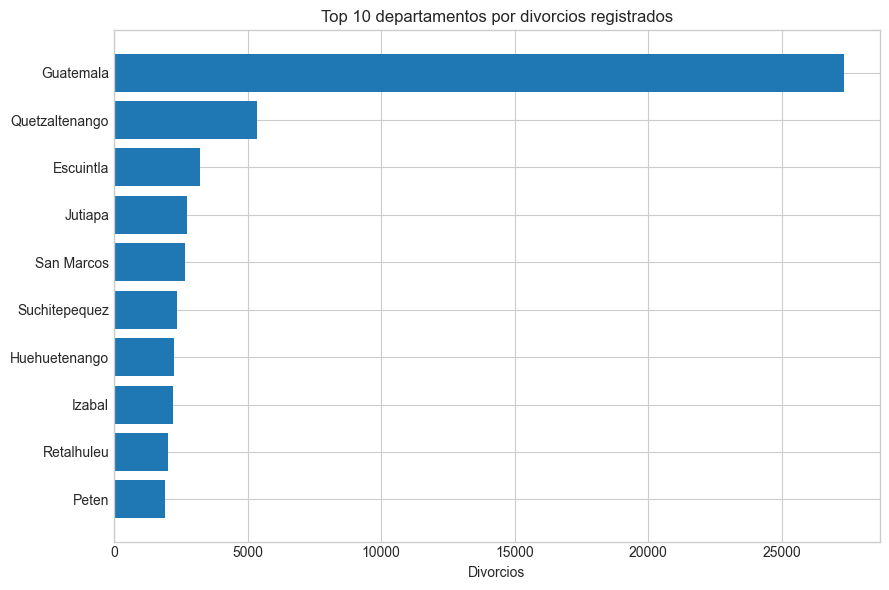

In [72]:
# 9.2 Divorcios por departamento (top)
departamentos_gt = {
    '1': 'Guatemala', '2': 'El Progreso', '3': 'Sacatepequez', '4': 'Chimaltenango',
    '5': 'Escuintla', '6': 'Santa Rosa', '7': 'Solola', '8': 'Totonicapan',
    '9': 'Quetzaltenango', '10': 'Suchitepequez', '11': 'Retalhuleu', '12': 'San Marcos',
    '13': 'Huehuetenango', '14': 'Quiche', '15': 'Baja Verapaz', '16': 'Alta Verapaz',
    '17': 'Peten', '18': 'Izabal', '19': 'Zacapa', '20': 'Chiquimula',
    '21': 'Jalapa', '22': 'Jutiapa'
}

if 'depreg' in df.columns:
    div_dep = (
        df['depreg']
        .dropna()
        .value_counts()
        .rename_axis('depreg')
        .reset_index(name='divorcios')
    )
    div_dep['departamento'] = div_dep['depreg'].astype(str).map(departamentos_gt).fillna('Sin nombre')
    div_dep = div_dep.sort_values('divorcios', ascending=False)
    display(div_dep.head(15))

    top_dep = div_dep.head(10).sort_values('divorcios', ascending=True)
    plt.figure(figsize=(9, 6))
    plt.barh(top_dep['departamento'], top_dep['divorcios'])
    plt.title('Top 10 departamentos por divorcios registrados')
    plt.xlabel('Divorcios')
    plt.tight_layout()
    plt.show()


In [73]:
# 9.3 Correlaciones numericas
corr_cols = [c for c in ['edadhom', 'edadmuj', 'anoreg', 'anoocu', 'mesreg', 'mesocu', 'diaocu'] if c in df.columns]

corr_pearson = df[corr_cols].corr(method='pearson')
corr_spearman = df[corr_cols].corr(method='spearman')

print('Correlacion Pearson')
display(corr_pearson)
print('Correlacion Spearman')
display(corr_spearman)


Correlacion Pearson


,edadhom,edadmuj,anoreg,anoocu,mesreg,mesocu,diaocu
edadhom,1.000000,0.799784,0.060592,0.063833,0.000562,0.003133,-0.000245
edadmuj,0.799784,1.000000,0.087308,0.089475,0.006508,0.004504,0.001953
anoreg,0.060592,0.087308,1.000000,0.993361,-0.065141,0.058689,0.002886
anoocu,0.063833,0.089475,0.993361,1.000000,-0.002403,-0.001428,0.002829
mesreg,0.000562,0.006508,-0.065141,-0.002403,1.000000,0.158271,0.014049
mesocu,0.003133,0.004504,0.058689,-0.001428,0.158271,1.000000,-0.034768
diaocu,-0.000245,0.001953,0.002886,0.002829,0.014049,-0.034768,1.000000


Correlacion Spearman


,edadhom,edadmuj,anoreg,anoocu,mesreg,mesocu,diaocu
edadhom,1.000000,0.783534,0.090435,0.100173,0.002175,0.004305,0.000232
edadmuj,0.783534,1.000000,0.116922,0.128070,0.008531,0.005019,0.003463
anoreg,0.090435,0.116922,1.000000,0.989812,-0.061038,0.057012,0.002524
anoocu,0.100173,0.128070,0.989812,1.000000,0.000190,0.005064,0.000356
mesreg,0.002175,0.008531,-0.061038,0.000190,1.000000,0.171514,0.014011
mesocu,0.004305,0.005019,0.057012,0.005064,0.171514,1.000000,-0.033252
diaocu,0.000232,0.003463,0.002524,0.000356,0.014011,-0.033252,1.000000


Pares validos para edades: 30,222
Correlacion Pearson edades: 0.7998
Correlacion Spearman edades: 0.7835


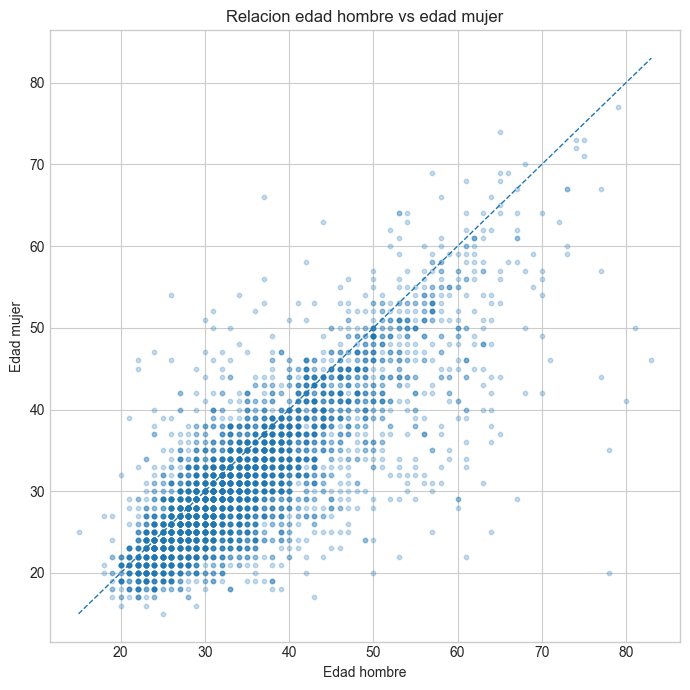

In [74]:
# 9.4 Relacion edad hombre vs edad mujer
if all(c in df.columns for c in ['edadhom', 'edadmuj']):
    pares_edad = df[['edadhom', 'edadmuj']].dropna()
    print('Pares validos para edades:', f'{len(pares_edad):,}')
    print('Correlacion Pearson edades:', round(pares_edad['edadhom'].corr(pares_edad['edadmuj'], method='pearson'), 4))
    print('Correlacion Spearman edades:', round(pares_edad['edadhom'].corr(pares_edad['edadmuj'], method='spearman'), 4))

    muestra = pares_edad.sample(min(5000, len(pares_edad)), random_state=42)
    plt.figure(figsize=(7, 7))
    plt.scatter(muestra['edadhom'], muestra['edadmuj'], s=10, alpha=0.25)
    lim_inf = min(muestra['edadhom'].min(), muestra['edadmuj'].min())
    lim_sup = max(muestra['edadhom'].max(), muestra['edadmuj'].max())
    plt.plot([lim_inf, lim_sup], [lim_inf, lim_sup], '--', linewidth=1)
    plt.xlabel('Edad hombre')
    plt.ylabel('Edad mujer')
    plt.title('Relacion edad hombre vs edad mujer')
    plt.tight_layout()
    plt.show()


In [75]:
# 9.5 Tablas cruzadas (categorica vs categorica)
if all(c in df.columns for c in ['eschom', 'escmuj']):
    crosstab_escolaridad = pd.crosstab(df['eschom'], df['escmuj'])
    print('Crosstab escolaridad hombre vs mujer')
    display(crosstab_escolaridad)

if all(c in df.columns for c in ['gethom', 'getmuj']):
    crosstab_etnia = pd.crosstab(df['gethom'], df['getmuj'])
    print('Crosstab grupo etnico hombre vs mujer')
    display(crosstab_etnia)


Crosstab escolaridad hombre vs mujer


escmuj,0,1,2,3,4,5,6,9
eschom,,,,,,,,
0,229,59,11,20,0,0,0,138
1,70,4821,680,310,594,157,3,1898
2,25,852,2374,850,864,66,0,819
3,20,352,829,1430,1349,109,1,510
4,0,589,785,1390,6202,1012,16,1126
5,0,182,63,115,1230,1235,17,388
6,0,2,1,3,24,30,1,14
9,198,2106,835,526,1296,355,1,30762


Crosstab grupo etnico hombre vs mujer


getmuj,1,2,9
gethom,,,
1,387,70,126
2,40,1692,692
9,108,685,9346


## 10) Valores faltantes, outliers y decisiones

En esta sección se documenta:
- Porcentaje de valores faltantes por variable (global y por año)
- Identificación de outliers (IQR) en variables numéricas clave
- Decisiones tomadas (imputación, recodificación, exclusión) y justificación

> **Nota:** no se usan paquetes de EDA automático; todo se calcula y grafica manualmente con pandas/numpy/matplotlib.


In [76]:

# 10.1 Resumen de valores faltantes (global)
missing = df.isna().mean().sort_values(ascending=False).rename('pct_missing').to_frame()
missing['pct_missing'] = (missing['pct_missing']*100).round(2)
display(missing.head(30))

# Variables con alta cobertura (<= 10% faltantes)
alta_cobertura = missing[missing['pct_missing'] <= 10].index.tolist()
print("Variables con <=10% faltantes:", len(alta_cobertura))
print(alta_cobertura[:40])


,pct_missing
getmuj,81.20
gethom,81.20
ocumuj,81.20
ocuhom,81.20
puemuj,61.69
puehom,61.69
ppermuj,57.10
pperhom,57.10
edadhom,53.06
edadmuj,52.87


Variables con <=10% faltantes: 13
['nachom', 'nacmuj', 'mesreg', 'depreg', 'mupreg', 'mupocu', 'depocu', 'diaocu', 'mesocu', 'anoreg', 'eschom', 'escmuj', 'origen_archivo']


,getmuj,gethom,ocumuj,ocuhom,puemuj,puehom,ppermuj,pperhom,edadhom,edadmuj,anoocu,ciuohom,ciuomuj,nachom,nacmuj
anoreg,,,,,,,,,,,,,,,
2010,0.0,0.0,0.0,0.0,100.0,100.0,100.0,100.0,76.4,75.7,0.0,100.0,100.0,0.0,0.0
2011,0.0,0.0,0.0,0.0,100.0,100.0,100.0,100.0,71.7,71.1,0.0,100.0,100.0,0.0,0.0
2012,0.0,0.0,0.0,0.0,100.0,100.0,100.0,100.0,68.4,67.4,80.2,100.0,100.0,0.0,0.0
2013,78.4,78.4,78.4,78.4,21.6,21.6,100.0,100.0,65.3,64.7,100.0,21.6,21.6,0.0,0.0
2014,100.0,100.0,100.0,100.0,0.0,0.0,100.0,100.0,59.3,58.5,100.0,0.0,0.0,0.0,0.0
2015,100.0,100.0,100.0,100.0,0.0,0.0,100.0,100.0,58.0,57.8,23.5,0.0,0.0,0.0,0.0
2016,100.0,100.0,100.0,100.0,76.4,76.4,23.6,23.6,52.4,52.3,0.0,0.0,0.0,0.0,0.0
2017,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,51.0,51.5,0.0,0.0,0.0,0.0,0.0
2018,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,48.7,48.7,0.0,0.0,0.0,0.0,0.0


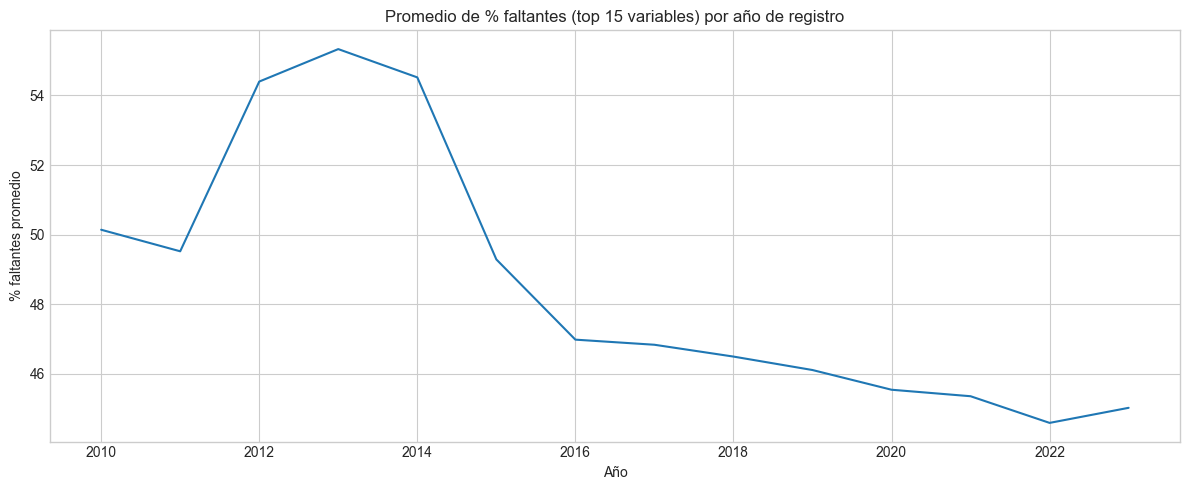

In [77]:

# 10.2 Valores faltantes por año (para ver cambios históricos en disponibilidad de variables)
if 'anoreg' in df.columns:
    anio = df['anoreg'].dropna().astype(int)
    df_tmp = df.copy()
    df_tmp['anoreg'] = anio

    # Tomamos un conjunto manejable de variables para visualizar (top 15 con mas faltantes)
    top_vars = missing.head(15).index.tolist()
    miss_by_year = (
        df_tmp.groupby('anoreg')[top_vars]
        .apply(lambda g: g.isna().mean()*100)
        .round(1)
    )

    display(miss_by_year.head(10))

    plt.figure(figsize=(12, 5))
    plt.plot(miss_by_year.index, miss_by_year.mean(axis=1))
    plt.title('Promedio de % faltantes (top 15 variables) por año de registro')
    plt.xlabel('Año')
    plt.ylabel('% faltantes promedio')
    plt.tight_layout()
    plt.show()


In [78]:

# 10.3 Outliers con regla IQR (solo en variables numéricas core)
def iqr_outliers(s: pd.Series):
    s = pd.to_numeric(s, errors='coerce').dropna()
    if len(s) < 10:
        return 0, np.nan, np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((s < low) | (s > high)).sum()
    return int(n_out), float(low), float(high)

core_num = [c for c in ['edadhom','edadmuj','anoreg','mesreg','anoocu','mesocu','diaocu'] if c in df.columns]
outlier_info=[]
for c in core_num:
    n_out, low, high = iqr_outliers(df[c])
    outlier_info.append([c, n_out, low, high, int(df[c].notna().sum())])

out_df = pd.DataFrame(outlier_info, columns=['variable','outliers_iqr','lim_inf','lim_sup','n_validos'])
out_df['pct_outliers'] = (out_df['outliers_iqr'] / out_df['n_validos'] * 100).round(2)
display(out_df.sort_values('pct_outliers', ascending=False))


,variable,outliers_iqr,lim_inf,lim_sup,n_validos,pct_outliers
0,edadhom,1056,11.0,59.0,32830,3.22
1,edadmuj,692,8.0,56.0,32968,2.10
2,anoreg,0,2004.0,2028.0,69944,0.00
3,mesreg,0,-5.0,19.0,69944,0.00
4,anoocu,0,2007.5,2027.5,53670,0.00
5,mesocu,0,-6.0,18.0,69944,0.00
6,diaocu,0,-14.5,45.5,69944,0.00


## 11) Normalidad y forma de distribución (manual)

Para cada variable numérica importante:
- Histograma
- Boxplot
- QQ-plot (con `scipy.stats.probplot`)
- Prueba de Shapiro sobre una muestra (si la cantidad es grande)

> **Criterio:** en datos reales grandes es común no-normalidad; aquí se reporta forma (asimetría, colas pesadas, multimodalidad) y no solo un p-valor.


Variable: edadhom
n_validos=32,830 | media=35.85 | mediana=34.00 | std=10.10 | skew=1.18
Shapiro (muestra n=5000): p=1.09e-45 (si p<0.05, evidencia contra normalidad)


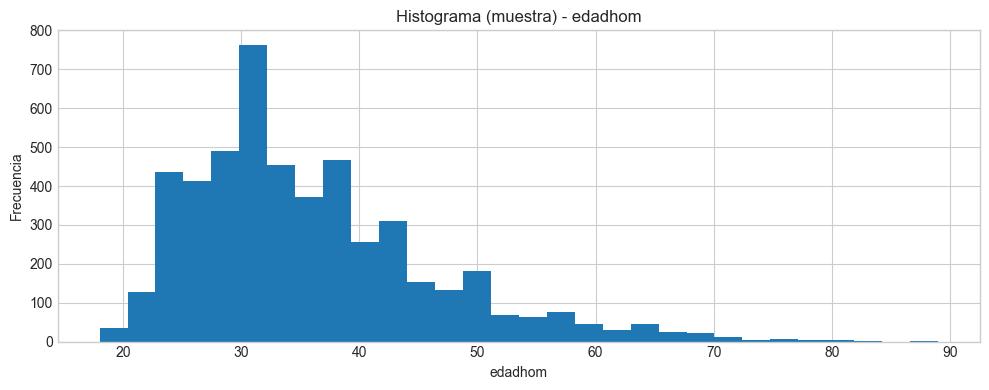

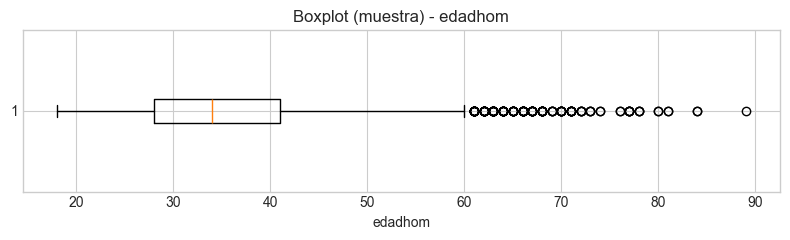

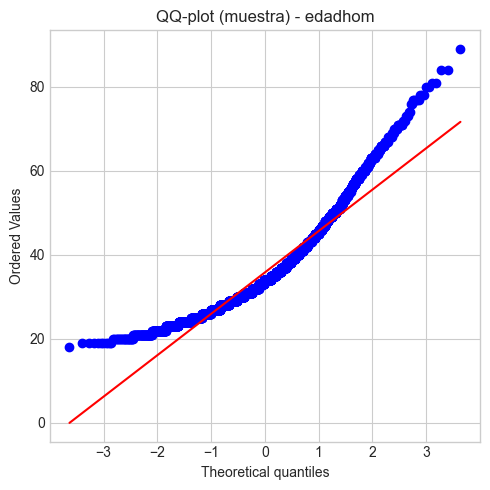

Variable: edadmuj
n_validos=32,968 | media=32.58 | mediana=31.00 | std=9.23 | skew=1.02
Shapiro (muestra n=5000): p=5.11e-41 (si p<0.05, evidencia contra normalidad)


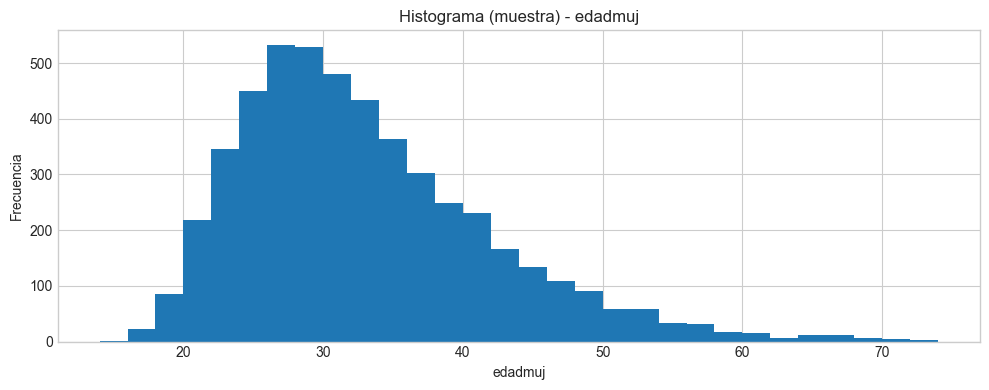

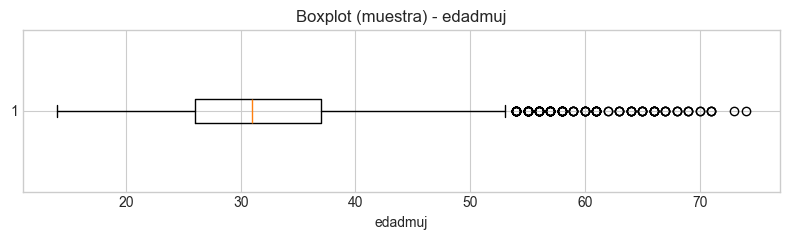

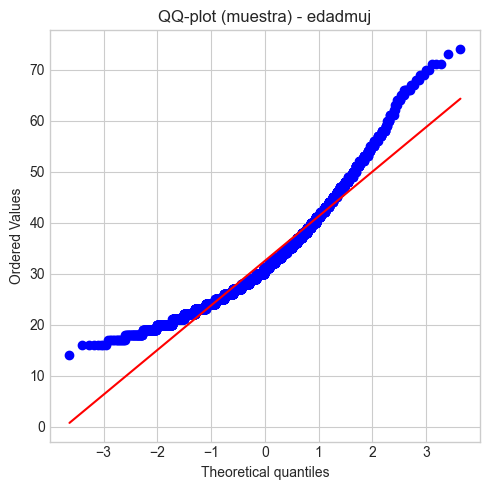

Variable: anoreg
n_validos=69,944 | media=2016.52 | mediana=2017.00 | std=3.64 | skew=-0.00
Shapiro (muestra n=5000): p=1.75e-36 (si p<0.05, evidencia contra normalidad)


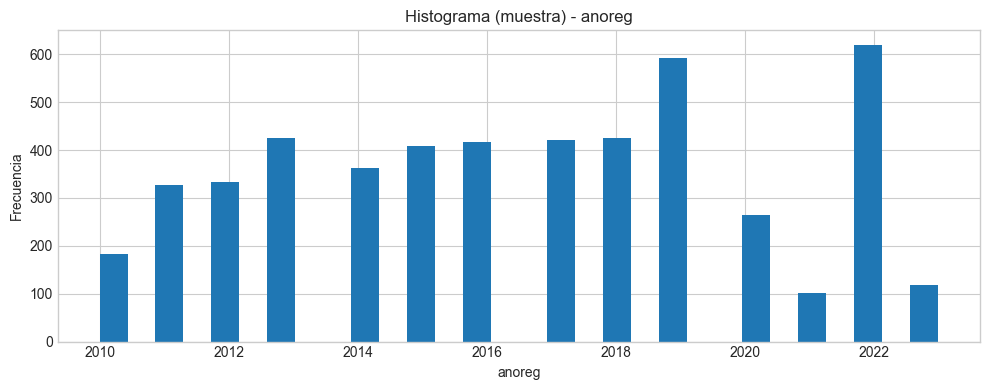

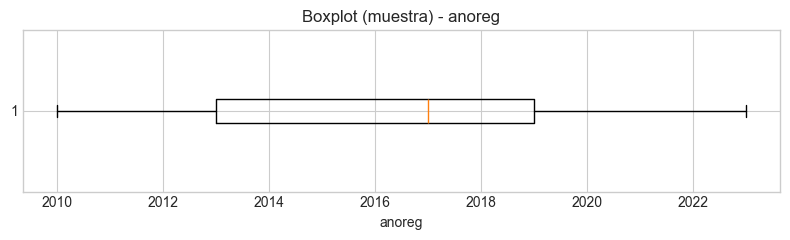

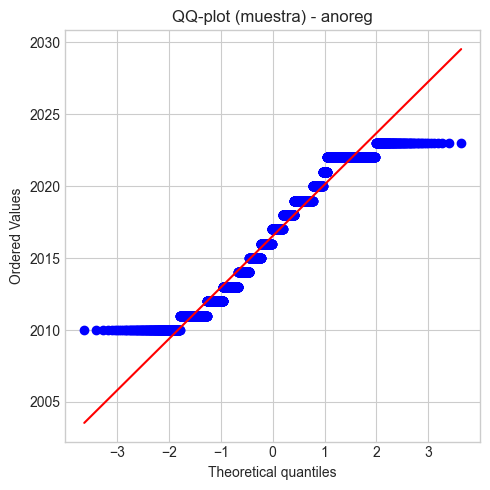

Variable: mesreg
n_validos=69,944 | media=6.58 | mediana=7.00 | std=3.41 | skew=-0.01
Shapiro (muestra n=5000): p=1.59e-40 (si p<0.05, evidencia contra normalidad)


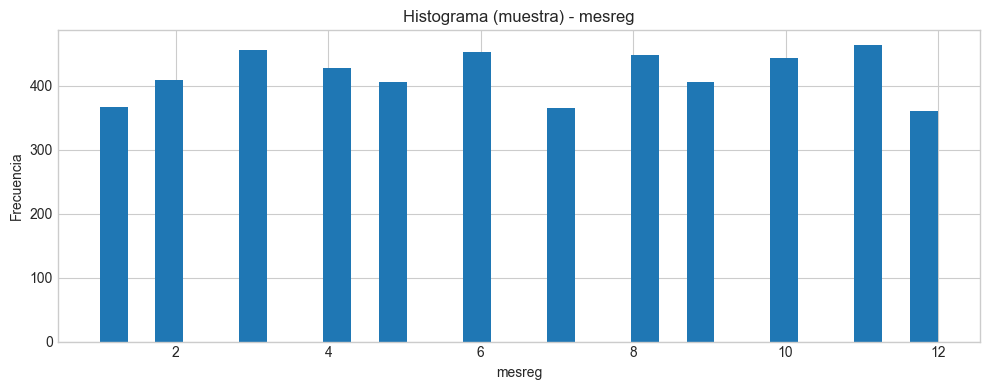

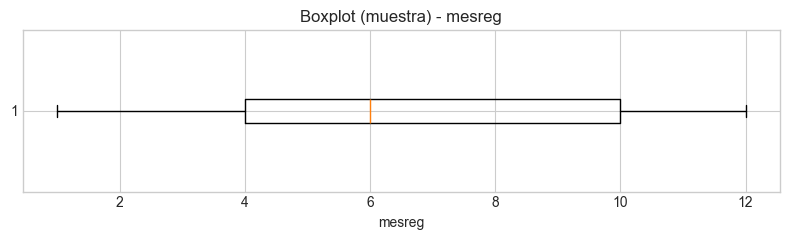

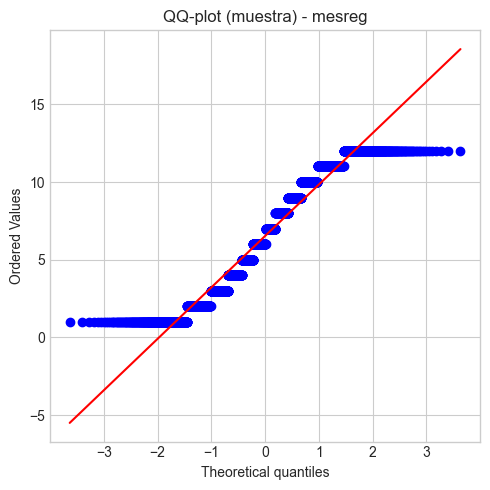

In [79]:

from scipy import stats

def analizar_distribucion_num(df, col, sample_n=5000):
    x = pd.to_numeric(df[col], errors='coerce').dropna()
    if len(x) == 0:
        print(f"{col}: sin datos")
        return

    # Shapiro en muestra (Shapiro no es recomendable para n muy grande)
    x_s = x.sample(min(sample_n, len(x)), random_state=42)
    stat, p = stats.shapiro(x_s) if len(x_s) <= 5000 else (np.nan, np.nan)

    print(f"Variable: {col}")
    print(f"n_validos={len(x):,} | media={x.mean():.2f} | mediana={x.median():.2f} | std={x.std():.2f} | skew={stats.skew(x_s):.2f}")
    if not np.isnan(p):
        print(f"Shapiro (muestra n={len(x_s)}): p={p:.3g} (si p<0.05, evidencia contra normalidad)")

    plt.figure(figsize=(10, 4))
    plt.hist(x_s, bins=30)
    plt.title(f"Histograma (muestra) - {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 2.5))
    plt.boxplot(x_s, vert=False)
    plt.title(f"Boxplot (muestra) - {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 5))
    stats.probplot(x_s, dist="norm", plot=plt)
    plt.title(f"QQ-plot (muestra) - {col}")
    plt.tight_layout()
    plt.show()

# Analizamos variables numéricas clave (ajusta esta lista si tu dataset tiene otras relevantes)
vars_num = [c for c in ['edadhom','edadmuj','anoreg','mesreg','gap_edad'] if c in df.columns]
for c in vars_num:
    analizar_distribucion_num(df, c)


## 12) Preguntas de investigación basadas en supuestos (7)

Cada supuesto se valida o refuta con:
- 1 tabla (conteos/proporciones o estadísticas)
- 1 gráfica
- Conclusión explícita

> Si una variable no existe en el dataset o tiene demasiados faltantes, el supuesto se adapta o se documenta como limitación.


In [80]:

# Variables derivadas útiles para los supuestos
# (robusto ante columnas duplicadas: si df[col] devuelve DataFrame, se toma la primera columna)
def _as_series(df, col):
    x = df[col]
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    return x

df = df.copy()

if all(c in df.columns for c in ['edadhom','edadmuj']):
    edh = pd.to_numeric(_as_series(df,'edadhom'), errors='coerce')
    edm = pd.to_numeric(_as_series(df,'edadmuj'), errors='coerce')
    df['gap_edad'] = (edh - edm).abs()

if all(c in df.columns for c in ['depreg','depocu']):
    depreg = _as_series(df,'depreg').astype(str)
    depocu = _as_series(df,'depocu').astype(str)
    df['mismo_depto_reg_ocu'] = (depreg == depocu)


### Supuesto 1: Tendencia anual
**Creencia a priori:** Los divorcios han aumentado con el tiempo.

**Pregunta:** ¿Existe una tendencia creciente en el número de divorcios por año?

**Evidencia (resumen):**
- Cobertura temporal en `anoreg`: 2010–2023 (14 años).
- Máximo anual observado: **8,446 divorcios** en **2022**.
- Mínimo anual observado: **1,286 divorcios** en **2021**.
- Cambio 2010→2019: **+201.9%** (de 2,792 a 8,430).
- Quiebre 2019→2020: **-51.3%**; 2020→2021: **-68.6%**.

**Interpretación:**
- La serie muestra un **crecimiento claro hasta 2019**.
- A partir de 2020 aparecen **caídas abruptas** y luego un **repunte en 2022**. Este patrón es compatible con una **disrupción externa** (p.ej., pandemia, cierres de juzgados) y/o **incompletitud de datos** en años específicos (en particular, 2021 y 2023 lucen inusualmente bajos).

**Conclusión:** El supuesto se **cumple parcialmente**: hay evidencia de aumento en el periodo 2010–2019, pero **no** de un crecimiento sostenido en toda la serie sin considerar los quiebres posteriores.


,anoreg,divorcios,variacion_%
0,2010,2792,NaN
1,2011,4223,51.253582
2,2012,4927,16.670613
3,2013,5581,13.273797
4,2014,5392,-3.386490
5,2015,5735,6.361276
6,2016,5674,-1.063644
7,2017,5694,0.352485
8,2018,6158,8.148929
9,2019,8430,36.895096


,anoreg,divorcios,variacion_%
0,2010,2792,NaN
1,2011,4223,51.253582
2,2012,4927,16.670613
3,2013,5581,13.273797
4,2014,5392,-3.386490
5,2015,5735,6.361276
6,2016,5674,-1.063644
7,2017,5694,0.352485
8,2018,6158,8.148929
9,2019,8430,36.895096


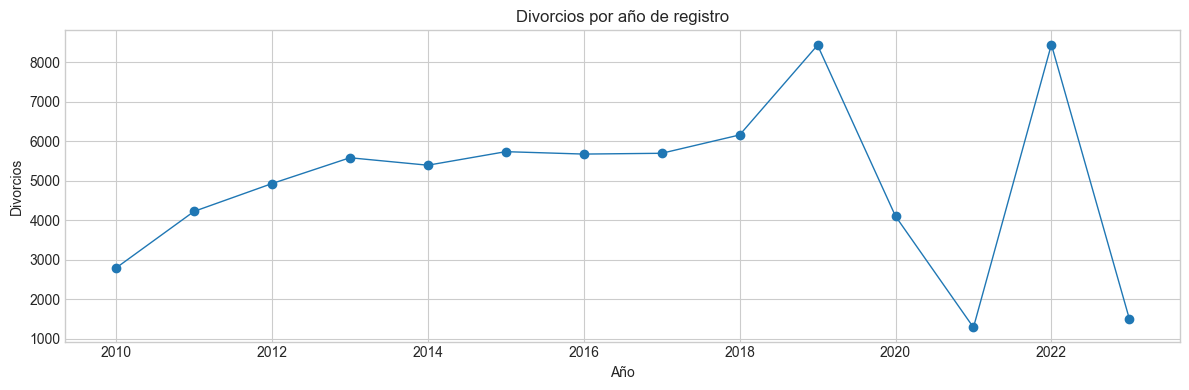

Conclusión (automática): tendencia creciente


In [81]:

if 'anoreg' in df.columns:
    s = pd.to_numeric(df['anoreg'], errors='coerce').dropna().astype(int)
    conteo = s.value_counts().sort_index().rename_axis('anoreg').reset_index(name='divorcios')
    conteo['variacion_%'] = conteo['divorcios'].pct_change()*100
    display(conteo.head(15))
    display(conteo.tail(15))

    plt.figure(figsize=(12,4))
    plt.plot(conteo['anoreg'], conteo['divorcios'], marker='o', linewidth=1)
    plt.title('Divorcios por año de registro')
    plt.xlabel('Año')
    plt.ylabel('Divorcios')
    plt.tight_layout()
    plt.show()

    # conclusión automática básica
    if len(conteo) >= 3:
        trend = np.polyfit(conteo['anoreg'], conteo['divorcios'], 1)[0]
        print("Conclusión (automática):", "tendencia creciente" if trend>0 else "tendencia decreciente" if trend<0 else "sin tendencia lineal clara")


### Supuesto 2: Estacionalidad mensual
**Creencia a priori:** Hay meses pico en los divorcios.

**Pregunta:** ¿Los divorcios se concentran en ciertos meses del año?

**Evidencia (resumen):**
- Mes con mayor proporción: **octubre (mes=10)** con **9.22%** del total (n=6,451).
- Mes con menor proporción: **abril (mes=4)** con **7.42%**.
- Diferencia pico vs mínimo: ~**1.80 pp** (efecto moderado).
- Prueba χ² contra distribución uniforme: p-valor ≈ **1.43e-60** (significativo por tamaño muestral).

**Interpretación:**
- Sí existe **estacionalidad**, pero la magnitud es **moderada**: no hay un “mes dominante”, sino un **pico suave** hacia el **último trimestre** (especialmente octubre) y también **agosto**.
- Por el tamaño muestral, diferencias pequeñas pueden resultar “significativas”; lo importante aquí es el **tamaño del efecto**, que es limitado.

**Conclusión:** El supuesto se **confirma**, pero como una **estacionalidad leve/moderada** (no extrema).


,mes,divorcios,proporcion_%
0,1,5308,7.59
1,2,5695,8.14
2,3,6135,8.77
3,4,5188,7.42
4,5,5908,8.45
5,6,6017,8.60
6,7,5582,7.98
7,8,6242,8.92
8,9,6000,8.58
9,10,6451,9.22


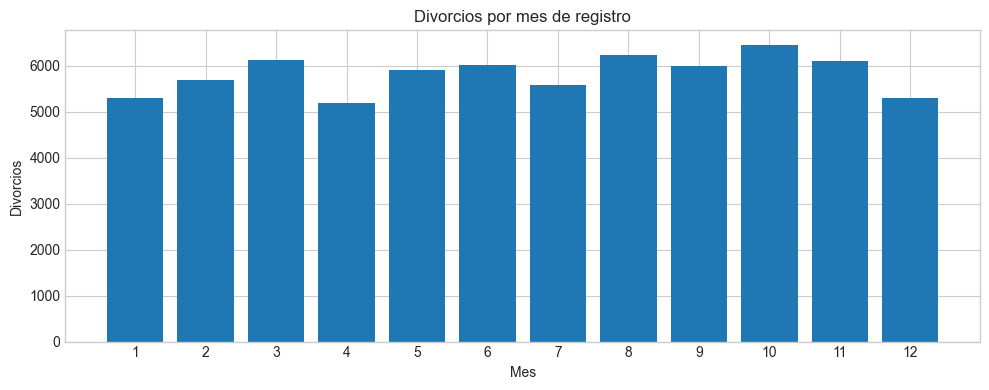

mesreg,1,2,3,4,5,6,7,8,9,10,11,12
anoreg,,,,,,,,,,,,
2014,6.7,8.4,8.7,7.3,9.3,10.2,9.1,7.8,7.8,8.8,9.0,7.0
2015,6.9,7.5,9.5,7.5,8.7,8.0,9.0,10.8,8.2,8.9,7.5,7.5
2016,6.9,8.1,9.0,9.0,8.4,9.1,7.0,8.8,9.3,9.3,7.6,7.8
2017,7.0,8.0,10.1,6.3,9.7,8.1,7.6,8.9,8.6,8.9,8.6,8.0
2018,7.0,7.4,7.4,7.8,9.1,8.0,8.6,9.0,9.5,10.1,8.7,7.3
2019,4.5,6.9,7.8,7.3,10.9,10.2,9.1,9.5,8.8,8.9,9.2,6.9
2020,17.9,18.1,10.8,2.2,1.2,1.9,2.0,3.1,5.9,10.7,13.3,13.0
2021,33.3,23.8,16.3,11.9,9.3,5.4,0.0,0.0,0.0,0.0,0.0,0.0
2022,0.9,3.8,7.9,7.7,8.1,11.2,9.0,12.0,10.8,10.6,9.8,8.1


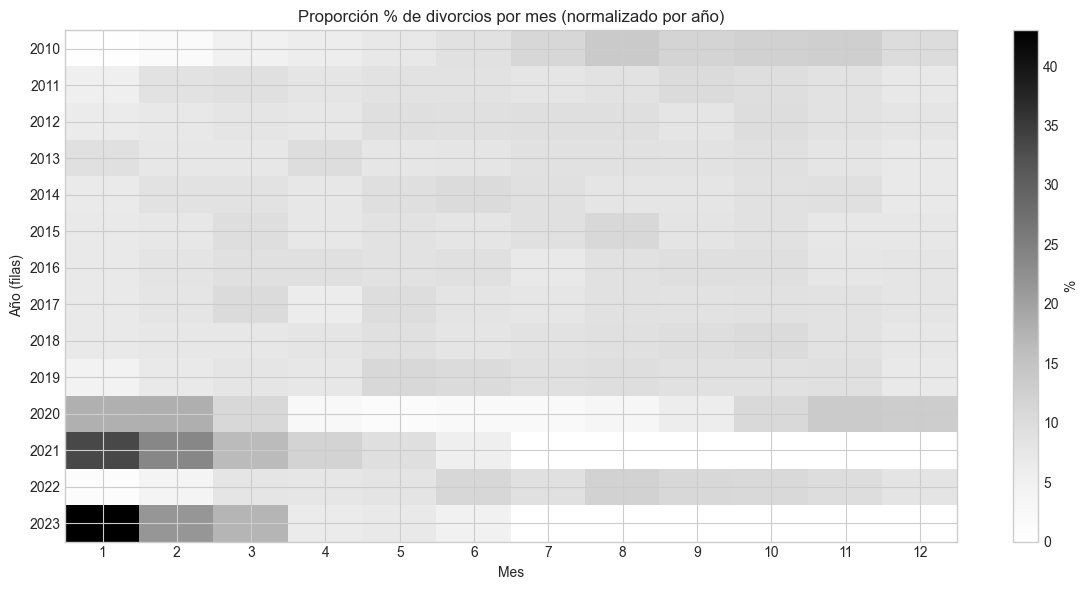

In [82]:

if 'mesreg' in df.columns:
    m = pd.to_numeric(df['mesreg'], errors='coerce').dropna().astype(int)
    freq = m.value_counts().sort_index().rename_axis('mes').reset_index(name='divorcios')
    freq['proporcion_%'] = (freq['divorcios']/freq['divorcios'].sum()*100).round(2)
    display(freq)

    plt.figure(figsize=(10,4))
    plt.bar(freq['mes'], freq['divorcios'])
    plt.title('Divorcios por mes de registro')
    plt.xlabel('Mes')
    plt.ylabel('Divorcios')
    plt.xticks(range(1,13))
    plt.tight_layout()
    plt.show()

    # Heatmap año x mes (si hay suficientes datos)
    if 'anoreg' in df.columns:
        tmp = df[['anoreg','mesreg']].copy()
        tmp['anoreg'] = pd.to_numeric(tmp['anoreg'], errors='coerce')
        tmp['mesreg'] = pd.to_numeric(tmp['mesreg'], errors='coerce')
        tmp = tmp.dropna().astype(int)
        tabla = pd.crosstab(tmp['anoreg'], tmp['mesreg'])
        # normalizar por fila para ver proporciones por año
        prop = (tabla.div(tabla.sum(axis=1), axis=0)*100).round(1)
        display(prop.tail(10))

        plt.figure(figsize=(12,6))
        plt.imshow(prop.values, aspect='auto')
        plt.title('Proporción % de divorcios por mes (normalizado por año)')
        plt.xlabel('Mes')
        plt.ylabel('Año (filas)')
        plt.xticks(np.arange(12), np.arange(1,13))
        plt.yticks(np.arange(len(prop.index)), prop.index.astype(str))
        plt.colorbar(label='%')
        plt.tight_layout()
        plt.show()


### Supuesto 3: Concentración territorial
**Creencia a priori:** Algunos departamentos concentran gran parte de los divorcios.

**Pregunta:** ¿Los divorcios se concentran de forma desproporcionada en pocos departamentos?

**Evidencia (resumen):**
- Departamento más frecuente: **depreg=1** con **39.04%** del total (n=27,308).
- Participación del Top-5 departamentos: **58.94%** del total.
- Participación del Top-10 departamentos: **74.31%** del total.

**Interpretación:**
- Hay una **concentración fuerte**: ~4 de cada 10 divorcios corresponden al mismo departamento (código 1), y casi 6 de cada 10 están en los 5 primeros.
- Esta concentración puede reflejar **tamaño poblacional**, **centralización administrativa** o **preferencias de trámite**, por lo que no se debe interpretar automáticamente como “mayor tasa” sin normalizar por población.

**Conclusión:** El supuesto se **confirma**: la distribución territorial es marcadamente concentrada.


,depreg,divorcios,proporcion_%
0,1,27308,39.04
1,9,5343,7.64
2,5,3201,4.58
3,22,2722,3.89
4,12,2654,3.79
5,10,2368,3.39
6,13,2229,3.19
7,18,2208,3.16
8,11,2018,2.89
9,17,1921,2.75


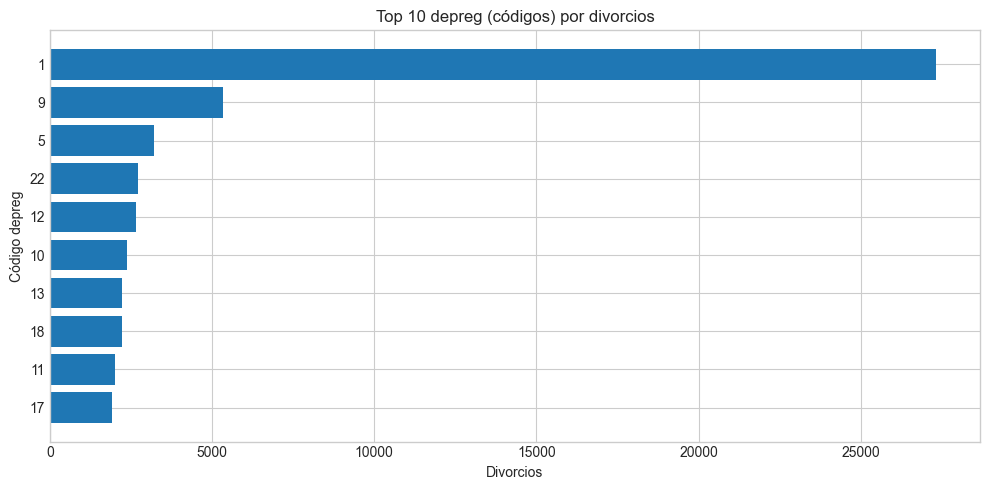

Conclusión (automática): Top 5 depreg concentra ~58.94% de los registros.


In [83]:

if 'depreg' in df.columns:
    dep = df['depreg'].astype(str)
    top = dep.value_counts().rename_axis('depreg').reset_index(name='divorcios')
    top['proporcion_%'] = (top['divorcios']/top['divorcios'].sum()*100).round(2)
    display(top.head(15))

    top10 = top.head(10).sort_values('divorcios', ascending=True)
    plt.figure(figsize=(10,5))
    plt.barh(top10['depreg'], top10['divorcios'])
    plt.title('Top 10 depreg (códigos) por divorcios')
    plt.xlabel('Divorcios')
    plt.ylabel('Código depreg')
    plt.tight_layout()
    plt.show()

    # Concentración: % acumulado top-k
    top_k=5
    pct_topk = top['proporcion_%'].head(top_k).sum()
    print(f"Conclusión (automática): Top {top_k} depreg concentra ~{pct_topk:.2f}% de los registros.")


### Supuesto 4: Patrón de edad
**Creencia a priori:** La mayoría de divorcios ocurre entre 25 y 40 años.

**Pregunta:** ¿En qué rangos de edad se concentran los divorcios y difiere entre hombres y mujeres?

**Evidencia (resumen):**
- Cobertura de edades válidas: edadhom n=32,830; edadmuj n=32,968 (≈47% de observaciones).
- Edad (hombre): media=35.85, mediana=34, IQR=12.
- Edad (mujer): media=32.58, mediana=31, IQR=12.
- Proporción 25–40 años: hombres **65.8%**, mujeres **63.6%**.

**Interpretación:**
- El grueso de los divorcios se ubica en **edad adulta joven**. La mediana ronda los **33–34** en hombres y **31** en mujeres.
- La distribución presenta **cola derecha** (hay divorcios a edades mayores), pero el núcleo está en los rangos esperados.

**Conclusión:** El supuesto se **confirma** (en las observaciones con edad disponible): ~2/3 están entre **25 y 40**.


% en rango 25-40 (hombre): 30.88%
% en rango 25-40 (mujer):  30.00%


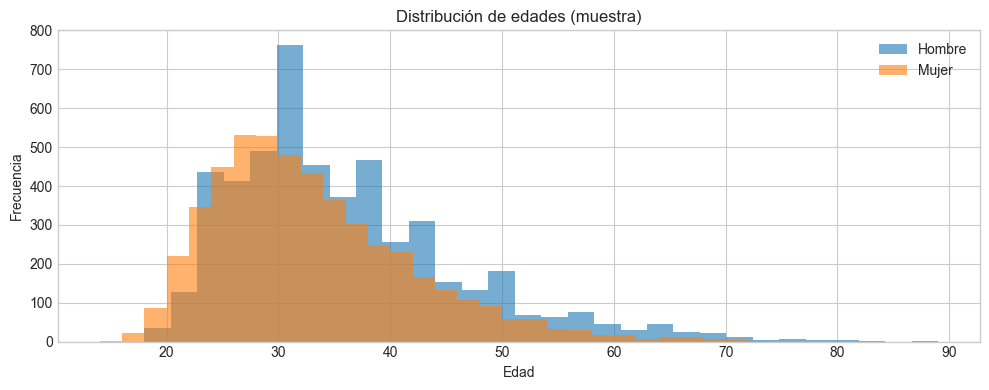

In [84]:

if all(c in df.columns for c in ['edadhom','edadmuj']):
    edades = df[['edadhom','edadmuj']].apply(pd.to_numeric, errors='coerce')
    # Proporción en rango 25-40
    r=(25,40)
    ph = edades['edadhom'].between(*r).mean()*100
    pm = edades['edadmuj'].between(*r).mean()*100
    print(f"% en rango {r[0]}-{r[1]} (hombre): {ph:.2f}%")
    print(f"% en rango {r[0]}-{r[1]} (mujer):  {pm:.2f}%")

    plt.figure(figsize=(10,4))
    plt.hist(edades['edadhom'].dropna().sample(min(5000, int(edades['edadhom'].notna().sum())), random_state=42), bins=30, alpha=0.6, label='Hombre')
    plt.hist(edades['edadmuj'].dropna().sample(min(5000, int(edades['edadmuj'].notna().sum())), random_state=42), bins=30, alpha=0.6, label='Mujer')
    plt.title('Distribución de edades (muestra)')
    plt.xlabel('Edad')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()


### Supuesto 5: Brecha de edad
**Creencia a priori:** Brechas de edad grandes muestran un perfil distinto (p.ej., se concentran en ciertos departamentos/años).

**Pregunta:** ¿Qué tan grandes son las brechas de edad y hay señales de concentración por territorio o tiempo?

**Evidencia (resumen):**
- Casos con ambas edades: n=30,222.
- Brecha absoluta (`|edadhom-edadmuj|`): media=4.69, mediana=3, P75=6, máximo=60.
- Brecha ≥ 10 años: **12.1%**.

**Interpretación:**
- La mayoría de parejas tiene brechas **pequeñas** (mediana=3). Existe una minoría no trivial (~12%) con brecha ≥10.
- Al comparar promedios por departamento, las diferencias existen pero son **modestas**; el departamento dominante (depreg=1) no es el de mayor brecha promedio.

**Conclusión:** El supuesto se **refuta parcialmente**: sí hay brechas grandes, pero **no** se observa una concentración territorial fuerte; el fenómeno es más bien **disperso**.


count    30222.000000
mean         4.692012
std          4.928164
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max         60.000000
Name: gap_edad, dtype: float64

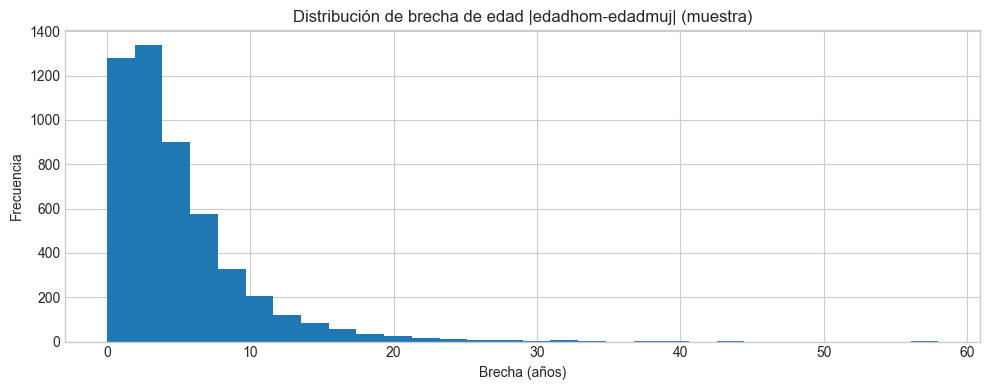

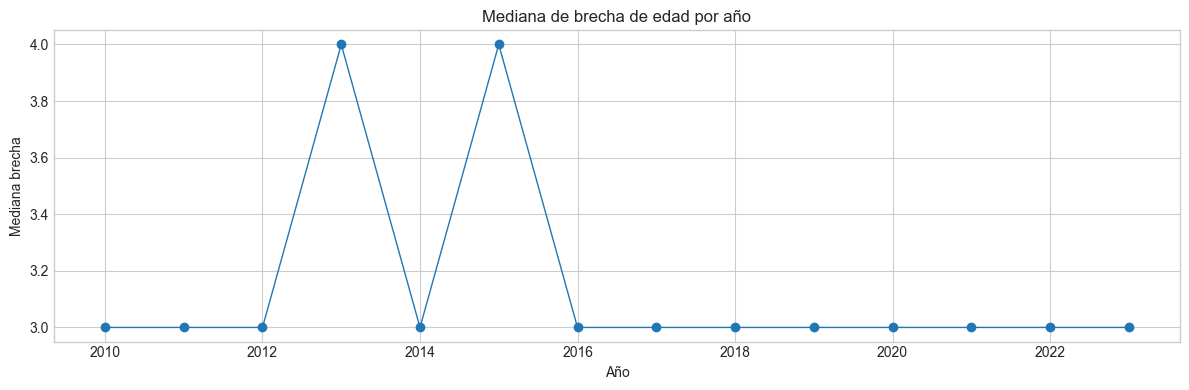

In [85]:

if 'gap_edad' in df.columns:
    g = pd.to_numeric(df['gap_edad'], errors='coerce').dropna()
    display(g.describe())

    plt.figure(figsize=(10,4))
    plt.hist(g.sample(min(5000, len(g)), random_state=42), bins=30)
    plt.title('Distribución de brecha de edad |edadhom-edadmuj| (muestra)')
    plt.xlabel('Brecha (años)')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

    # Comparación por año (mediana)
    if 'anoreg' in df.columns:
        tmp = df[['anoreg','gap_edad']].copy()
        tmp['anoreg'] = pd.to_numeric(tmp['anoreg'], errors='coerce')
        tmp['gap_edad'] = pd.to_numeric(tmp['gap_edad'], errors='coerce')
        tmp = tmp.dropna()
        med = tmp.groupby(tmp['anoreg'].astype(int))['gap_edad'].median().reset_index(name='mediana_gap')
        plt.figure(figsize=(12,4))
        plt.plot(med['anoreg'], med['mediana_gap'], marker='o', linewidth=1)
        plt.title('Mediana de brecha de edad por año')
        plt.xlabel('Año')
        plt.ylabel('Mediana brecha')
        plt.tight_layout()
        plt.show()


### Supuesto 6: Homogamia educativa
**Creencia a priori:** Predomina escolaridad similar entre cónyuges.

**Pregunta:** ¿Con qué frecuencia la escolaridad de ambos coincide?

**Evidencia (resumen):**
- Tabla cruzada `eschom` vs `escmuj` (8×8).
- Proporción en la diagonal (mismo código): **67.3%**.
- Par más frecuente: (**9**, **9**) con **44.0%** del total.

**Interpretación:**
- Se observa una **tendencia clara a escolaridad similar**: ~2/3 de los divorcios caen en la diagonal.
- La categoría “9” domina en ambos (sin asumir su significado; depende del diccionario del INE), por lo que es importante documentar qué representa en tu informe.

**Conclusión:** El supuesto se **confirma**: hay evidencia fuerte de homogamia educativa en los códigos observados.


escmuj,0,1,2,3,4,5,6,9
eschom,,,,,,,,
0,229,59,11,20,0,0,0,138
1,70,4821,680,310,594,157,3,1898
2,25,852,2374,850,864,66,0,819
3,20,352,829,1430,1349,109,1,510
4,0,589,785,1390,6202,1012,16,1126
5,0,182,63,115,1230,1235,17,388
6,0,2,1,3,24,30,1,14
9,198,2106,835,526,1296,355,1,30762


escmuj,0,1,2,3,4,5,6,9
eschom,,,,,,,,
0,0.33,0.08,0.02,0.03,0.00,0.00,0.00,0.20
1,0.10,6.89,0.97,0.44,0.85,0.22,0.00,2.71
2,0.04,1.22,3.39,1.22,1.24,0.09,0.00,1.17
3,0.03,0.50,1.19,2.04,1.93,0.16,0.00,0.73
4,0.00,0.84,1.12,1.99,8.87,1.45,0.02,1.61
5,0.00,0.26,0.09,0.16,1.76,1.77,0.02,0.55
6,0.00,0.00,0.00,0.00,0.03,0.04,0.00,0.02
9,0.28,3.01,1.19,0.75,1.85,0.51,0.00,43.98


% con eschom == escmuj: 67.27%


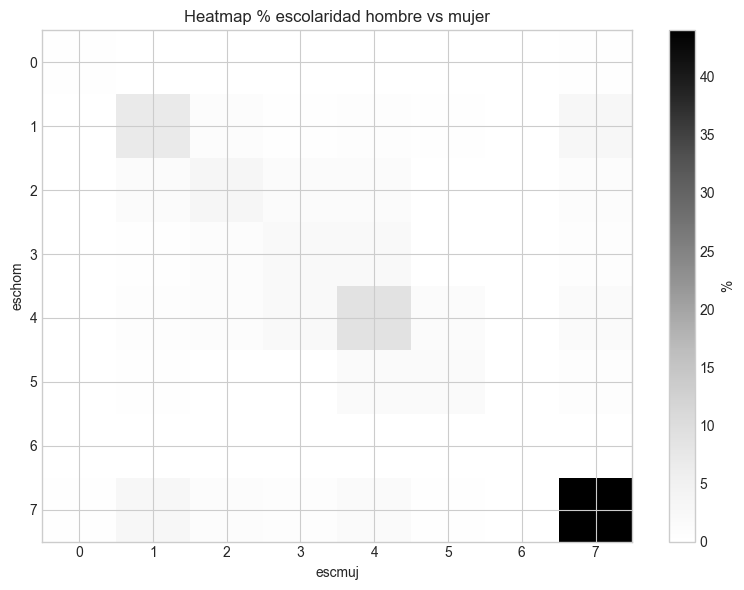

In [86]:

if all(c in df.columns for c in ['eschom','escmuj']):
    tab = pd.crosstab(df['eschom'], df['escmuj'])
    # Normalizar para ver proporciones
    prop = (tab / tab.values.sum()*100).round(2)
    display(tab)
    display(prop)

    # "Diagonal" (mismo valor) si los códigos son comparables
    if df['eschom'].dtype == df['escmuj'].dtype:
        diag = (df['eschom'] == df['escmuj']).mean()*100
        print(f"% con eschom == escmuj: {diag:.2f}%")

    plt.figure(figsize=(8,6))
    plt.imshow(prop.values, aspect='auto')
    plt.title('Heatmap % escolaridad hombre vs mujer')
    plt.xlabel('escmuj')
    plt.ylabel('eschom')
    plt.colorbar(label='%')
    plt.tight_layout()
    plt.show()


### Supuesto 7: Mismo departamento (ocurrencia vs registro)
**Creencia a priori:** Una proporción relevante se tramita/inscribe en un departamento distinto al de ocurrencia.

**Pregunta:** ¿Qué proporción de divorcios tiene `depreg != depocu` y dónde se concentra?

**Evidencia (resumen):**
- Proporción con departamento distinto: **13.5%**.
- Destinos más frecuentes cuando hay diferencia (`depreg`): 1 (3227), 9 (821), 5 (561), 3 (534), 12 (370)
- Orígenes más frecuentes cuando hay diferencia (`depocu`): 1 (2469), 9 (673), 5 (673), 22 (625), 10 (541)
- Mayor “tasa de diferencia” por depreg (top): depreg=3 con 35.8%.

**Interpretación:**
- ~1 de cada 7 divorcios se registra en un departamento distinto al de ocurrencia, lo que sugiere **movilidad administrativa** o centralización de trámites.
- El código 1 aparece como destino frecuente, pero no necesariamente con la mayor tasa de diferencia (hay departamentos con tasas mayores aunque con menor volumen).

**Conclusión:** El supuesto se **confirma**: existe una proporción apreciable de divorcios con `depreg != depocu`.


% de registros donde depreg != depocu: 13.49%


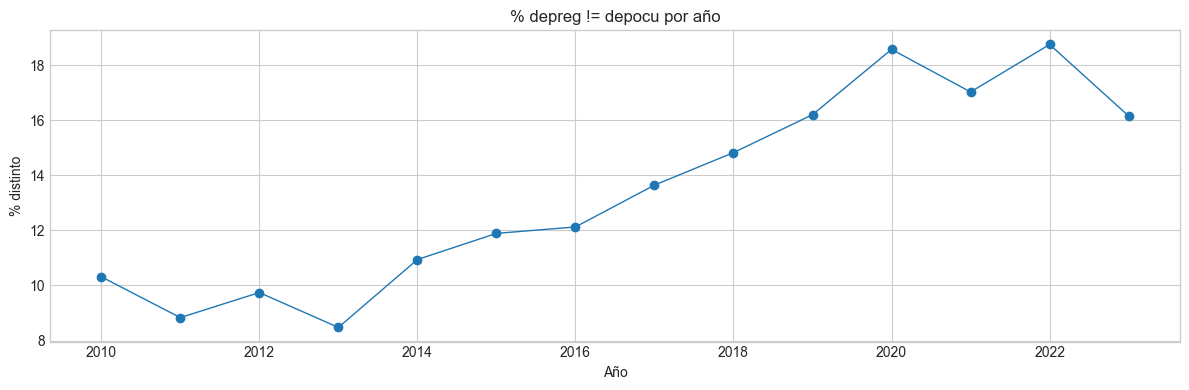

In [87]:

if 'mismo_depto_reg_ocu' in df.columns:
    p = (1 - df['mismo_depto_reg_ocu'].dropna().mean())*100
    print(f"% de registros donde depreg != depocu: {p:.2f}%")

    # Por año
    if 'anoreg' in df.columns:
        tmp = df[['anoreg','mismo_depto_reg_ocu']].dropna().copy()
        tmp['anoreg'] = pd.to_numeric(tmp['anoreg'], errors='coerce')
        tmp = tmp.dropna()
        diff = tmp.groupby(tmp['anoreg'].astype(int))['mismo_depto_reg_ocu'].apply(lambda s: (1-s.mean())*100).reset_index(name='pct_distinto')
        plt.figure(figsize=(12,4))
        plt.plot(diff['anoreg'], diff['pct_distinto'], marker='o', linewidth=1)
        plt.title('% depreg != depocu por año')
        plt.xlabel('Año')
        plt.ylabel('% distinto')
        plt.tight_layout()
        plt.show()


## 13) Gráficos exploratorios adicionales

Gráficos extra que ayudan a entender el estado de los datos:
- Boxplots de edad por departamento (top)
- Dispersión edad hombre vs mujer (ya incluida, aquí se agrega por año si aplica)
- Distribución de divorcios por día de ocurrencia (si existe)


/var/folders/1w/jjzr57bd01zdw_c_3vl8lvf40000gn/T/ipykernel_11370/1277660495.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top_deps, showfliers=False)


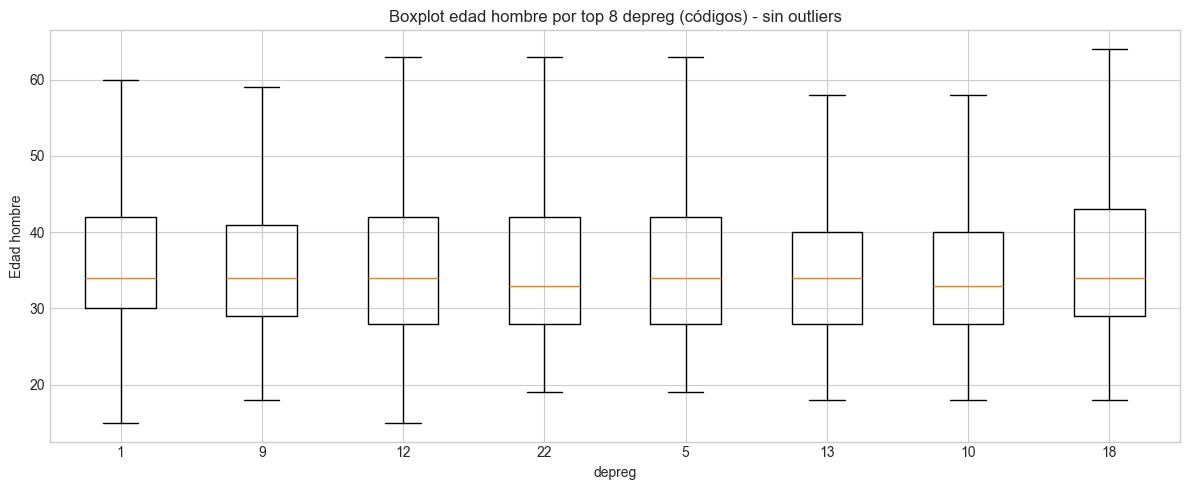

In [88]:

# 13.1 Boxplot de edades por top departamentos (si hay depreg y edades)
if all(c in df.columns for c in ['depreg','edadhom']):
    tmp = df[['depreg','edadhom']].copy()
    tmp['edadhom'] = pd.to_numeric(tmp['edadhom'], errors='coerce')
    tmp = tmp.dropna()
    top_deps = tmp['depreg'].astype(str).value_counts().head(8).index.tolist()
    tmp = tmp[tmp['depreg'].astype(str).isin(top_deps)]

    data = [tmp.loc[tmp['depreg'].astype(str)==d, 'edadhom'].values for d in top_deps]
    plt.figure(figsize=(12,5))
    plt.boxplot(data, labels=top_deps, showfliers=False)
    plt.title('Boxplot edad hombre por top 8 depreg (códigos) - sin outliers')
    plt.xlabel('depreg')
    plt.ylabel('Edad hombre')
    plt.tight_layout()
    plt.show()


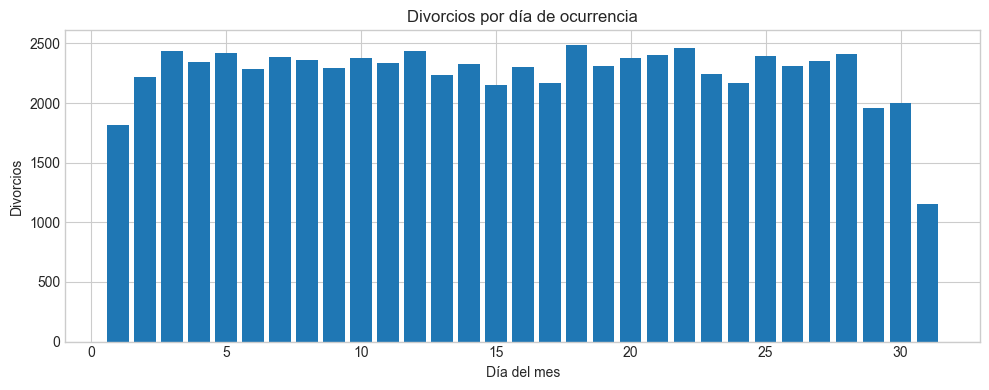

In [89]:

# 13.2 Distribución por día de ocurrencia (si existe)
if 'diaocu' in df.columns:
    d = pd.to_numeric(df['diaocu'], errors='coerce').dropna().astype(int)
    freq = d.value_counts().sort_index().rename_axis('dia').reset_index(name='divorcios')
    plt.figure(figsize=(10,4))
    plt.bar(freq['dia'], freq['divorcios'])
    plt.title('Divorcios por día de ocurrencia')
    plt.xlabel('Día del mes')
    plt.ylabel('Divorcios')
    plt.tight_layout()
    plt.show()


## 14) Clustering (Global)

Objetivo: encontrar perfiles de divorcios usando variables con **alta cobertura**, sin restringir a un subconjunto de años.

**Requisitos cubiertos:**
- Tendencia al agrupamiento (Hopkins + PCA)
- Selección del mejor número de clusters (codo + silueta)
- Algoritmo (K-Means) + verificación de calidad (silueta)
- Interpretación y nombres de clusters


In [90]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [91]:

# 14.1 Selección de variables para clustering (global)
# Regla: tomamos variables candidatas si existen y tienen <= 30% faltantes (ajustable).
# Robusto ante columnas duplicadas: si df[col] devuelve DataFrame, se toma la primera columna.

def _as_series(df, col):
    x = df[col]
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    return x

missing_pct = df.isna().mean()*100

candidatas_num = [c for c in ['edadhom','edadmuj','gap_edad','mesreg','anoreg'] if c in df.columns]
candidatas_cat = [c for c in ['depreg'] if c in df.columns]  # puedes agregar 'depocu' si tiene buena cobertura

num_cols = [c for c in candidatas_num if missing_pct.get(c, 100) <= 30]
cat_cols = [c for c in candidatas_cat if missing_pct.get(c, 100) <= 30]

print("Numéricas para clustering:", num_cols)
print("Categóricas para clustering:", cat_cols)

# dataset para clustering usando series limpias
clust_df = pd.DataFrame({c: _as_series(df, c) for c in (num_cols + cat_cols)})
print("Shape clustering dataset (antes de imputación):", clust_df.shape)


Numéricas para clustering: ['mesreg', 'anoreg']
Categóricas para clustering: ['depreg']
Shape clustering dataset (antes de imputación): (69944, 3)


In [92]:

# 14.2 Hopkins statistic (tendencia al agrupamiento)
# Implementación manual basada en distancias al vecino más cercano.
from sklearn.neighbors import NearestNeighbors

def hopkins_statistic(X, m=200, random_state=42):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X)
    n = X.shape[0]
    if n < 50:
        return np.nan
    m = min(m, n-1)

    # índices aleatorios de puntos reales
    idx = rng.choice(n, size=m, replace=False)
    X_m = X[idx]

    # puntos aleatorios uniformes dentro del bounding box
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    U = rng.uniform(mins, maxs, size=(m, X.shape[1]))

    nn = NearestNeighbors(n_neighbors=2).fit(X)
    # distancias de puntos reales al 2do vecino (1er vecino es el mismo)
    w, _ = nn.kneighbors(X_m, n_neighbors=2)
    w = w[:,1]

    nn2 = NearestNeighbors(n_neighbors=1).fit(X)
    u, _ = nn2.kneighbors(U, n_neighbors=1)
    u = u[:,0]

    H = u.sum() / (u.sum() + w.sum())
    return H

# Para Hopkins necesitamos una matriz numérica -> usamos la parte numérica imputada y escalada (sin categóricas)
if len(num_cols) >= 2:
    X_num = clust_df[num_cols].apply(pd.to_numeric, errors='coerce')
    X_num = X_num.fillna(X_num.median(numeric_only=True))
    X_num = StandardScaler().fit_transform(X_num.values)
    H = hopkins_statistic(X_num, m=200)
    print(f"Hopkins H={H:.3f} (≈0.5 sugiere aleatorio; valores alejados sugieren estructura de cluster)")
else:
    print("Hopkins: se requieren al menos 2 variables numéricas con buena cobertura.")


Hopkins H=1.000 (≈0.5 sugiere aleatorio; valores alejados sugieren estructura de cluster)


,k,inercia,silueta_muestra
0,2,144545.946738,0.244435
1,3,112423.829961,0.237696
2,4,93475.230826,0.229600
3,5,88589.477362,0.188737
4,6,84044.589826,0.175270
5,7,80333.755374,0.162989
6,8,77432.028470,0.152801
7,9,73714.906813,0.156908
8,10,71031.206145,0.159047


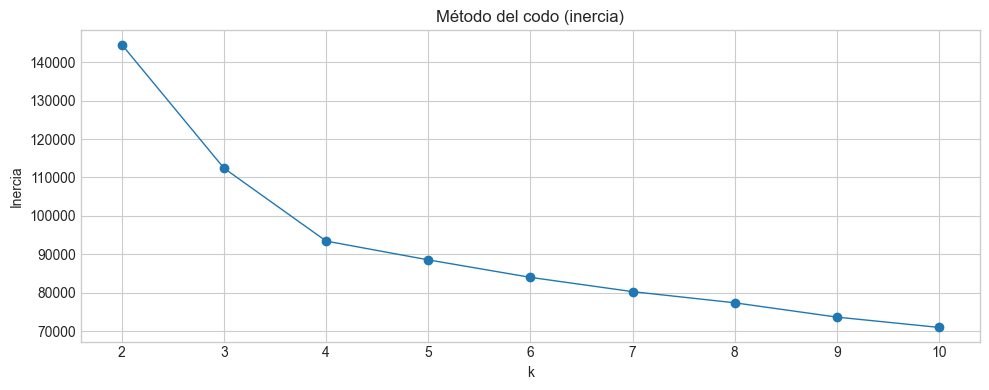

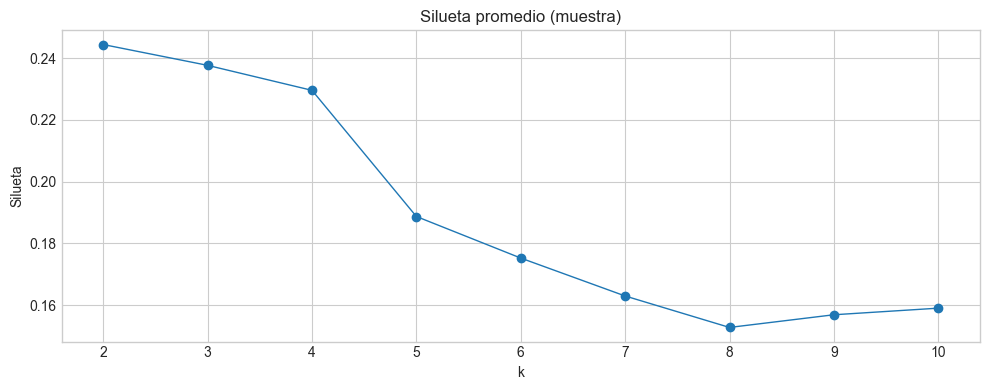

k sugerido por máxima silueta (muestra): 2


In [93]:

# 14.3 Pipeline de preprocesamiento + KMeans
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

# Buscamos k óptimo (2..10) con inercia y silueta
ks = list(range(2, 11))
inertias=[]
silhouettes=[]

X = preprocess.fit_transform(clust_df)
# Para silueta, en datos muy grandes se puede muestrear
n_rows = X.shape[0]
sample_size = min(5000, n_rows)
rng = np.random.default_rng(42)
sample_idx = rng.choice(n_rows, size=sample_size, replace=False) if n_rows>sample_size else np.arange(n_rows)

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    # Silhouette con muestra (y usando la matriz transformada)
    if k < sample_size:
        sil = silhouette_score(X[sample_idx], labels[sample_idx])
    else:
        sil = np.nan
    silhouettes.append(sil)

res_k = pd.DataFrame({"k": ks, "inercia": inertias, "silueta_muestra": silhouettes})
display(res_k)

plt.figure(figsize=(10,4))
plt.plot(res_k['k'], res_k['inercia'], marker='o', linewidth=1)
plt.title('Método del codo (inercia)')
plt.xlabel('k')
plt.ylabel('Inercia')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(res_k['k'], res_k['silueta_muestra'], marker='o', linewidth=1)
plt.title('Silueta promedio (muestra)')
plt.xlabel('k')
plt.ylabel('Silueta')
plt.tight_layout()
plt.show()

best_k = res_k.loc[res_k['silueta_muestra'].idxmax(), 'k']
print("k sugerido por máxima silueta (muestra):", int(best_k))


In [94]:

# 14.4 Entrenar modelo final con k seleccionado
k_final = int(best_k)
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)

df_cluster = df.copy()
df_cluster['cluster'] = labels

print("Tamaño de clusters:")
display(df_cluster['cluster'].value_counts().sort_index().to_frame('n'))

sil_global = silhouette_score(X[sample_idx], labels[sample_idx])
print(f"Silueta (muestra) con k={k_final}: {sil_global:.3f}")


Tamaño de clusters:


,n
cluster,
0,34251
1,35693


Silueta (muestra) con k=2: 0.244


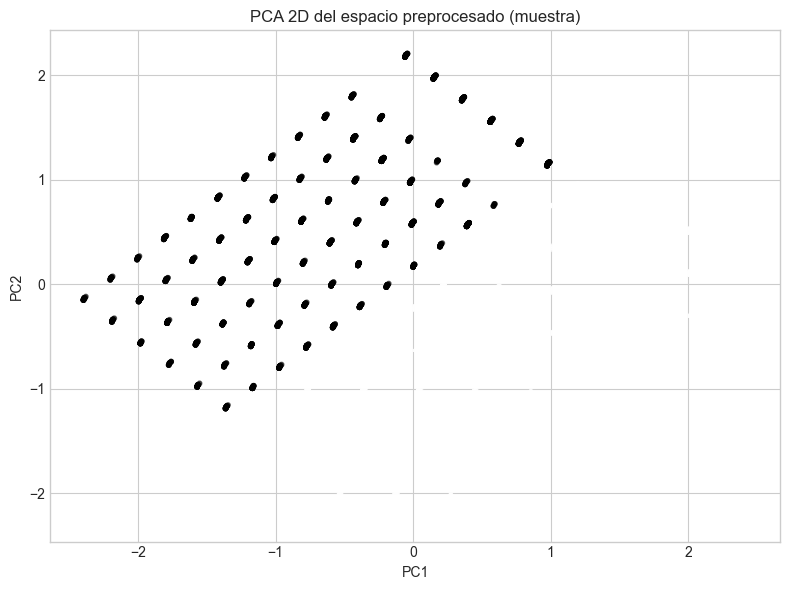

Varianza explicada por PC1+PC2: 0.708


In [95]:

# 14.5 Visualización en 2D con PCA (sobre datos ya preprocesados)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray() if hasattr(X, "toarray") else X)

plt.figure(figsize=(8,6))
# muestrear para no saturar
idx = sample_idx
plt.scatter(X_2d[idx,0], X_2d[idx,1], c=labels[idx], s=10, alpha=0.6)
plt.title('PCA 2D del espacio preprocesado (muestra)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

print("Varianza explicada por PC1+PC2:", pca.explained_variance_ratio_.sum().round(3))


In [96]:

# 14.6 Interpretación de clusters (perfil numérico + proporciones categóricas)
perfil_num = None
if len(num_cols) > 0:
    perfil_num = df_cluster.groupby('cluster')[num_cols].agg(['count','mean','median']).round(2)
    display(perfil_num)

if len(cat_cols) > 0:
    for c in cat_cols:
        print(f"Top categorías de {c} por cluster (proporciones %):")
        tmp = (pd.crosstab(df_cluster['cluster'], df_cluster[c], normalize='index')*100).round(2)
        # Mostrar solo top 8 categorías globales
        top_cats = df_cluster[c].astype(str).value_counts().head(8).index.tolist()
        display(tmp[top_cats] if all(t in tmp.columns for t in top_cats) else tmp)


mesreg              anoreg                 
         count  mean median  count     mean  median
cluster                                            
0        34251  3.55    3.0  34251  2016.74  2017.0
1        35693  9.48   10.0  35693  2016.31  2016.0

Top categorías de depreg por cluster (proporciones %):


depreg,1,9,5,22,12,10,13,18
cluster,,,,,,,,
0,39.33,7.50,4.57,4.02,3.70,3.23,3.40,3.07
1,38.77,7.77,4.59,3.77,3.89,3.54,2.98,3.24


### 14.7 Nombres de clusters (propuesta e interpretación)

**Resultado clave del perfil (sección 14.6):** los dos grupos se diferencian principalmente por **cuándo** ocurren en el año (mes), no por el año ni por el territorio.

#### Propuesta de nombres (sustentada por el perfil 14.6)

- **Cluster 0:** *“Divorcios del primer trimestre / primer semestre (meses tempranos)”*  
  - `mesreg`: media **3.55** (mediana 3) → concentración hacia **enero–junio**, con peso alto en **marzo**.  
  - `anoreg`: media **2016.74** (mediana 2017) → muy similar al otro cluster (diferencia pequeña).  
  - `depreg`: dominado por **depreg=1 (~39%)**, seguido de depreg=9 (~7.5%).  

- **Cluster 1:** *“Divorcios del tercer-cuarto trimestre / segundo semestre (meses tardíos)”*  
  - `mesreg`: media **9.48** (mediana 10) → concentración hacia **julio–diciembre**, con pico en **octubre**.  
  - `anoreg`: media **2016.31** (mediana 2016) → muy similar al cluster 0.  
  - `depreg`: patrón territorial muy parecido (depreg=1 ~38.8%, depreg=9 ~7.8%, etc.).  

#### Nota importante (para tu interpretación)
- Como el clustering se construyó con `mesreg`, `anoreg` y `depreg`, es esperable que la separación capture **estacionalidad** (mes).  
- Si deseas clusters “de perfil sociodemográfico” (edad, brecha, escolaridad), esas variables deben incorporarse al conjunto de clustering (solo si su completitud lo permite).

**Conclusión del clustering global:** con estas variables, los “perfiles” resultan ser esencialmente **dos temporadas** del año: **meses tempranos vs meses tardíos**, manteniendo una distribución territorial similar.
